# SANITYCHECKING
**This notebook is used for any function testing and debugging.**

**This file replaces most functions of test folder**

## ENV INSTALLING

In [1]:
! python.exe -m pip install --upgrade pip
! pip install -r ../requirements.txt

## BASELINE CHECKING
BASELINE AND TRAINGING BASIC FUNC SAN CHECKING

In [1]:
import sys
from pathlib import Path

r_folder = Path.cwd().parent
if str(r_folder) not in sys.path:
    sys.path.append(str(r_folder))

import torch
from torch import optim

from src.utils.helpers import set_seed, get_device, count_parameters
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import prepare_link_prediction_data, summarize_split
from src.models.baselines import GCNBaseline
from src.models.train import fit
from src.evaluation.evaluate import evaluate_split

In [2]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

config = {
    "hidden_channels": 64,
    "emb_channels": 64,
    "predictor_hidden_channels": 64,
    "dropout": 0.2,
    "lr": 1e-2,
    "weight_decay": 1e-4,
    "epochs": 50,
}

data = get_data_object(dataset_name, root = r_folder / "data")
print(data)
print("num_nodes:", data.num_nodes)
print("num_features:", data.num_features)
print("edge_index shape:", data.edge_index.shape if data.edge_index is not None else None)
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print("Train split summary:")
print(summarize_split(train_data))

print("\nVal split summary:")
print(summarize_split(val_data))

print("\nTest split summary:")
print(summarize_split(test_data))

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
num_nodes: 2708
num_features: 1433
edge_index shape: torch.Size([2, 10556])
Train split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 7392), 'edge_label_shape': (7392,), 'num_positive_labels': 3696, 'num_negative_labels': 3696}

Val split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 1054), 'edge_label_shape': (1054,), 'num_positive_labels': 527, 'num_negative_labels': 527}

Test split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 8446), 'edge_label_index_shape': (2, 2110), 'edge_label_shape': (2110,), 'num_positive_labels': 1055, 'num_negative_labels': 1055}


In [3]:
model = GCNBaseline(
    in_channels=train_data.num_features,
    hidden_channels=config["hidden_channels"],
    emb_channels=config["emb_channels"],
    predictor_hidden_channels=config["predictor_hidden_channels"],
    dropout=config["dropout"],
).to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=config["lr"],
    weight_decay=config["weight_decay"],
)

print(model)
print("Trainable parameters:", count_parameters(model))

x = train_data.x.to(device)
edge_index = train_data.edge_index.to(device)
edge_label_index = train_data.edge_label_index.to(device)

with torch.no_grad():
    logits = model(x, edge_index, edge_label_index)

print("logits shape:", logits.shape)
print("num edge labels:", train_data.edge_label.shape)

GCNBaseline(
  (encoder): GCNEncoder(
    (conv1): GCNConv(1433, 64)
    (conv2): GCNConv(64, 64)
  )
  (predictor): MLPLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Trainable parameters: 112449
logits shape: torch.Size([7392])
num edge labels: torch.Size([7392])


In [4]:
history = fit(
    model=model,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,
    device=device,
    epochs=config["epochs"],
    verbose=True,
)

print("Training finished.")
print("Last train loss:", history["train_loss"][-1])
if len(history["val_loss"]) > 0:
    print("Last val loss:", history["val_loss"][-1])

Training: 100%|██████████| 50/50 [00:00<00:00, 120.01it/s, best_val=0.4524, train_loss=0.0018, val_loss=1.1762]

Training finished.
Last train loss: 0.0018266375409439206
Last val loss: 1.1761828660964966


Train metrics: {'loss': 0.20346099138259888, 'auc': 0.9879544663939955, 'ap': 0.9837987298276403, 'hits@100': 0.9066558480262756}
Val metrics: {'loss': 0.4524369239807129, 'auc': 0.8807398579190505, 'ap': 0.8927229774345096, 'hits@100': 0.7685009241104126}
Test metrics: {'loss': 0.39694541692733765, 'auc': 0.9117324408706003, 'ap': 0.9132822646965291, 'hits@100': 0.7355450391769409}


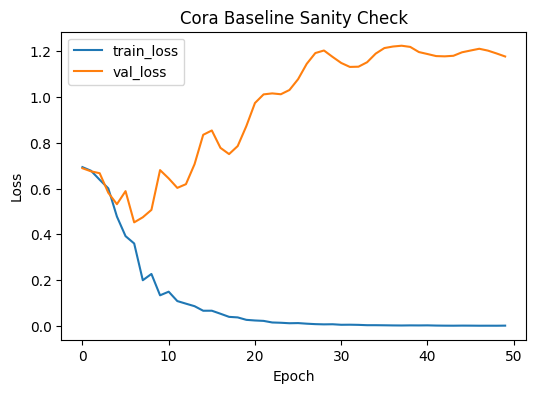

In [5]:
train_metrics = evaluate_split(model, train_data, device, hits_ks=[100])
val_metrics = evaluate_split(model, val_data, device, hits_ks=[100])
test_metrics = evaluate_split(model, test_data, device, hits_ks=[100])

print("Train metrics:", train_metrics)
print("Val metrics:", val_metrics)
print("Test metrics:", test_metrics)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
if len(history["val_loss"]) > 0:
    plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cora Baseline Sanity Check")
plt.legend()
plt.show()

## ELPH CHECKING
ELPH and ELPH w/ Edge Awareness + Log1p Basic func san checking

### MH and HLL TESTING

In [6]:
import sys
from pathlib import Path

import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import make_edge_index_undirected
from src.utils.helpers import set_seed
from src.utils.sketches import (
    initialize_minhash,
    initialize_hll,
    propagate_minhash,
    propagate_hll,
    hamming_similarity,
    estimate_hll_cardinality,
    estimate_intersection_size,
)

In [7]:
set_seed(42)

data = get_data_object("Cora", root=project_root / "data")
data = make_edge_index_undirected(data)

print(data)
print("num_nodes:", data.num_nodes)
print("num_features:", data.num_features)
print("edge_index shape:", data.edge_index.shape if data.edge_index is not None else None)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
num_nodes: 2708
num_features: 1433
edge_index shape: torch.Size([2, 10556])


In [8]:
num_nodes = data.num_nodes
#num_perm = 16
num_perm = 64
hll_p = 8   # TRY HIGHER VAULE
num_hops = 2

minhash_0 = initialize_minhash(num_nodes=num_nodes, num_perm=num_perm, base_seed=42)
hll_0 = initialize_hll(num_nodes=num_nodes, p=hll_p, base_seed=42)

print("minhash_0 shape:", minhash_0.shape)
print("hll_0 shape:", hll_0.shape)

print("\nminhash_0 sample (first 3 nodes):")
print(minhash_0[:3])

print("\nhll_0 sample (first 3 nodes):")
print(hll_0[:3])

minhash_0 shape: torch.Size([2708, 64])
hll_0 shape: torch.Size([2708, 256])

minhash_0 sample (first 3 nodes):
tensor([[2084277512, 2101851875, 1816161293, 1588765180, 1820233151, 1933216098,
          674617335,  426083063, 2115685626, 1145245549, 2112371322,  855546615,
         1540499828,  841660814,  934742888,  767405766, 1012239575,  308112666,
          679990110, 1410601146,  681628370, 1310697140,  159408303,  446507871,
          593411558,  144684077, 1266377950,  107032657, 1367513116, 1077049328,
         1584603836, 1114150008, 1012545956,  313108376, 1255015186,  971186097,
         1384013228, 1022192434, 1371522627, 1257520050,  340559800, 1269383178,
         1992021337, 2118713363, 1497349027,  687953903,  960264744, 1927078399,
          404756462, 1715435478,  539579971, 1238464536, 1673152125, 1025568169,
         1956366129, 1990237935, 1963944022, 1874378574, 2089128051,   77708552,
         1895950007, 1158959420, 1961820859, 1786603853],
        [1545431408,

In [9]:
edge_index = data.edge_index
assert edge_index is not None

minhash_hops = propagate_minhash(minhash_0, edge_index, num_hops=num_hops)
hll_hops = propagate_hll(hll_0, edge_index, num_hops=num_hops)

print("number of minhash hop tensors:", len(minhash_hops))
print("number of hll hop tensors:", len(hll_hops))

for i, sketch in enumerate(minhash_hops):
    print(f"minhash hop {i} shape: {sketch.shape}")

for i, sketch in enumerate(hll_hops):
    print(f"hll hop {i} shape: {sketch.shape}")

number of minhash hop tensors: 3
number of hll hop tensors: 3
minhash hop 0 shape: torch.Size([2708, 64])
minhash hop 1 shape: torch.Size([2708, 64])
minhash hop 2 shape: torch.Size([2708, 64])
hll hop 0 shape: torch.Size([2708, 256])
hll hop 1 shape: torch.Size([2708, 256])
hll hop 2 shape: torch.Size([2708, 256])


In [10]:
node_ids = [0, 1, 2]

for node_id in node_ids:
    print(f"\n===== Node {node_id} =====")
    for hop in range(len(minhash_hops)):
        print(f"Hop {hop} MinHash:")
        print(minhash_hops[hop][node_id])

    for hop in range(len(hll_hops)):
        print(f"Hop {hop} HLL:")
        print(hll_hops[hop][node_id])


===== Node 0 =====
Hop 0 MinHash:
tensor([2084277512, 2101851875, 1816161293, 1588765180, 1820233151, 1933216098,
         674617335,  426083063, 2115685626, 1145245549, 2112371322,  855546615,
        1540499828,  841660814,  934742888,  767405766, 1012239575,  308112666,
         679990110, 1410601146,  681628370, 1310697140,  159408303,  446507871,
         593411558,  144684077, 1266377950,  107032657, 1367513116, 1077049328,
        1584603836, 1114150008, 1012545956,  313108376, 1255015186,  971186097,
        1384013228, 1022192434, 1371522627, 1257520050,  340559800, 1269383178,
        1992021337, 2118713363, 1497349027,  687953903,  960264744, 1927078399,
         404756462, 1715435478,  539579971, 1238464536, 1673152125, 1025568169,
        1956366129, 1990237935, 1963944022, 1874378574, 2089128051,   77708552,
        1895950007, 1158959420, 1961820859, 1786603853])
Hop 1 MinHash:
tensor([ 205556593,  654611704,  656734102, 1827459009, 1185280106,  482193763,
         4634

In [11]:
u, v = 0, 1

for hop in range(len(minhash_hops)):
    sim = hamming_similarity(
        minhash_hops[hop][u].unsqueeze(0),
        minhash_hops[hop][v].unsqueeze(0),
    )
    print(f"Hop {hop} MinHash similarity between node {u} and node {v}: {sim.item():.4f}")

Hop 0 MinHash similarity between node 0 and node 1: 0.0000
Hop 1 MinHash similarity between node 0 and node 1: 0.0000
Hop 2 MinHash similarity between node 0 and node 1: 0.0000


In [12]:
for hop in range(len(hll_hops)):
    card_est = estimate_hll_cardinality(hll_hops[hop][:5])
    print(f"Hop {hop} cardinality estimates for first 5 nodes:")
    print(card_est)

Hop 0 cardinality estimates for first 5 nodes:
tensor([1.0020, 1.0020, 1.0020, 1.0020, 1.0020])
Hop 1 cardinality estimates for first 5 nodes:
tensor([3.0177, 3.0177, 5.0495, 1.0020, 5.0495])
Hop 2 cardinality estimates for first 5 nodes:
tensor([ 7.0975,  6.0714, 76.3273,  1.0020, 14.3974])


In [13]:
u, v = 0, 1

for hop_u in range(len(minhash_hops)):
    for hop_v in range(len(minhash_hops)):
        inter_est = estimate_intersection_size(
            minhash_a=minhash_hops[hop_u][u].unsqueeze(0),
            minhash_b=minhash_hops[hop_v][v].unsqueeze(0),
            hll_a=hll_hops[hop_u][u].unsqueeze(0),
            hll_b=hll_hops[hop_v][v].unsqueeze(0),
        )
        print(
            f"Intersection estimate between node {u} hop {hop_u} "
            f"and node {v} hop {hop_v}: {inter_est.item():.4f}"
        )

Intersection estimate between node 0 hop 0 and node 1 hop 0: 0.0000
Intersection estimate between node 0 hop 0 and node 1 hop 1: 0.0000
Intersection estimate between node 0 hop 0 and node 1 hop 2: 0.0000
Intersection estimate between node 0 hop 1 and node 1 hop 0: 0.0000
Intersection estimate between node 0 hop 1 and node 1 hop 1: 0.0000
Intersection estimate between node 0 hop 1 and node 1 hop 2: 0.0000
Intersection estimate between node 0 hop 2 and node 1 hop 0: 0.0000
Intersection estimate between node 0 hop 2 and node 1 hop 1: 0.0000
Intersection estimate between node 0 hop 2 and node 1 hop 2: 0.0000


In [14]:
u = 0

for hop in range(len(minhash_hops)):
    self_inter = estimate_intersection_size(
        minhash_a=minhash_hops[hop][u].unsqueeze(0),
        minhash_b=minhash_hops[hop][u].unsqueeze(0),
        hll_a=hll_hops[hop][u].unsqueeze(0),
        hll_b=hll_hops[hop][u].unsqueeze(0),
    )
    self_card = estimate_hll_cardinality(hll_hops[hop][u].unsqueeze(0))

    print(
        f"Hop {hop}: self-intersection = {self_inter.item():.4f}, "
        f"self-cardinality = {self_card.item():.4f}"
    )

Hop 0: self-intersection = 1.0020, self-cardinality = 1.0020
Hop 1: self-intersection = 3.0177, self-cardinality = 3.0177
Hop 2: self-intersection = 7.0975, self-cardinality = 7.0975


#### MinHash Debug

In [15]:
edge_index = data.edge_index
assert edge_index is not None

src, dst = edge_index
num_nodes = data.num_nodes

neighbors = {i: set() for i in range(num_nodes)}
for u, v in zip(src.tolist(), dst.tolist()):
    neighbors[v].add(u)

found_pair = None
for u in range(num_nodes):
    for v in range(u + 1, num_nodes):
        common = neighbors[u].intersection(neighbors[v])
        if len(common) > 0:
            found_pair = (u, v, len(common))
            break
    if found_pair is not None:
        break

print(found_pair)

(0, 926, 1)


In [16]:
u, v = 0, 926
for hop in range(len(minhash_hops)):
    sim = hamming_similarity(
        minhash_hops[hop][u].unsqueeze(0),
        minhash_hops[hop][v].unsqueeze(0),
    )
    print(f"Hop {hop} MinHash similarity between node {u} and node {v}: {sim.item():.4f}")

Hop 0 MinHash similarity between node 0 and node 926: 0.0000
Hop 1 MinHash similarity between node 0 and node 926: 0.4062
Hop 2 MinHash similarity between node 0 and node 926: 0.5000


In [17]:
for hop_u in range(len(minhash_hops)):
    for hop_v in range(len(minhash_hops)):
        inter_est = estimate_intersection_size(
            minhash_a=minhash_hops[hop_u][u].unsqueeze(0),
            minhash_b=minhash_hops[hop_v][v].unsqueeze(0),
            hll_a=hll_hops[hop_u][u].unsqueeze(0),
            hll_b=hll_hops[hop_v][v].unsqueeze(0),
        )
        print(
            f"Intersection estimate between node {u} hop {hop_u} "
            f"and node {v} hop {hop_v}: {inter_est.item():.4f}"
        )

Intersection estimate between node 0 hop 0 and node 926 hop 0: 0.0000
Intersection estimate between node 0 hop 0 and node 926 hop 1: 0.0000
Intersection estimate between node 0 hop 0 and node 926 hop 2: 1.0709
Intersection estimate between node 0 hop 1 and node 926 hop 0: 0.0000
Intersection estimate between node 0 hop 1 and node 926 hop 1: 1.2260
Intersection estimate between node 0 hop 1 and node 926 hop 2: 0.6641
Intersection estimate between node 0 hop 2 and node 926 hop 0: 0.7763
Intersection estimate between node 0 hop 2 and node 926 hop 1: 1.2199
Intersection estimate between node 0 hop 2 and node 926 hop 2: 3.5487


### FEATURES TESTING

In [27]:
import sys
from pathlib import Path

import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import make_edge_index_undirected
from src.utils.helpers import set_seed
from src.utils.features import (
    build_structural_features,
    estimate_a_features,
    estimate_b_features,
    estimate_node_cardinalities,
    estimate_pairwise_intersections
)

In [28]:
# SMALL BATCH TESTING
edge_index = data.edge_index
assert edge_index is not None

edge_batch = edge_index[:, :8]

print("edge_batch shape:", edge_batch.shape)
print(edge_batch)

edge_batch shape: torch.Size([2, 8])
tensor([[   0,    0,    0,    1,    1,    1,    2,    2],
        [ 633, 1862, 2582,    2,  652,  654,    1,  332]])


In [29]:
num_hops = 2

pairwise_intersections = estimate_pairwise_intersections(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    num_hops=num_hops,
)

print("Number of hop-pair intersection tensors:", len(pairwise_intersections))
print("Expected:", (num_hops + 1) * (num_hops + 1))

for key in sorted(pairwise_intersections.keys()):
    value = pairwise_intersections[key]
    print(f"{key}: shape={value.shape}, min={value.min().item():.4f}, max={value.max().item():.4f}")

Number of hop-pair intersection tensors: 9
Expected: 9
(0, 0): shape=torch.Size([8]), min=0.0000, max=0.0000
(0, 1): shape=torch.Size([8]), min=0.7073, max=1.4202
(0, 2): shape=torch.Size([8]), min=0.0000, max=0.9981
(1, 0): shape=torch.Size([8]), min=0.8959, max=1.4202
(1, 1): shape=torch.Size([8]), min=0.0000, max=1.3413
(1, 2): shape=torch.Size([8]), min=2.7725, max=6.1626
(2, 0): shape=torch.Size([8]), min=0.0000, max=1.2199
(2, 1): shape=torch.Size([8]), min=1.3281, max=9.5409
(2, 2): shape=torch.Size([8]), min=0.0000, max=6.1747


In [30]:
a_hat_flat = estimate_a_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    num_hops=num_hops,
)

print("a_hat_flat shape:", a_hat_flat.shape)
print(a_hat_flat)
print("A-hat min:", a_hat_flat.min().item())
print("A-hat max:", a_hat_flat.max().item())

a_hat_flat shape: torch.Size([8, 9])
tensor([[0.0000, 0.9902, 0.0000, 0.8959, 0.0000, 2.8004, 0.0000, 1.7736, 0.0000],
        [0.0000, 1.0709, 0.0000, 1.2260, 0.0000, 2.4736, 0.0000, 1.2519, 0.0000],
        [0.0000, 0.7073, 0.2908, 0.8959, 0.0000, 0.8785, 0.0000, 1.5020, 0.4497],
        [0.0000, 1.4202, 0.0000, 0.9430, 0.0000, 3.5999, 0.0000, 2.7596, 0.0000],
        [0.0000, 1.1608, 0.0000, 1.0373, 0.0000, 0.7961, 0.0000, 0.0787, 0.0000],
        [0.0000, 1.0020, 0.0000, 1.0373, 0.0000, 0.9784, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.9430, 0.0000, 1.4202, 0.0000, 2.7596, 0.0000, 3.5999, 0.0000],
        [0.0000, 0.9468, 0.0000, 0.9468, 0.0000, 4.2691, 0.0000, 7.6474, 0.0000]])
A-hat min: 0.0
A-hat max: 7.6473541259765625


In [31]:
b_hat = estimate_b_features(
    edge_index=edge_batch,
    hll_hops=hll_hops,
    a_hat_flat=a_hat_flat,
    num_hops=num_hops,
)

print("b_hat shape:", b_hat.shape)
print(b_hat)
print("B-hat min:", b_hat.min().item())
print("B-hat max:", b_hat.max().item())

b_hat shape: torch.Size([8, 4])
tensor([[ 1.1316,  0.0000,  1.1316, 67.3918],
        [ 0.7209,  0.3542,  1.7348, 68.5702],
        [ 1.4146,  0.9587,  1.4146,  0.9587],
        [ 0.6545,  0.0000,  2.6863, 64.9184],
        [ 0.8196,  2.1789,  0.0000,  4.0246],
        [ 0.9784,  2.0753,  0.0000,  0.0000],
        [ 2.6863, 64.9184,  0.6545,  0.0000],
        [ 3.1559, 59.3614,  3.1559,  4.9456]])
B-hat min: 0.0
B-hat max: 68.57018280029297


In [32]:
structural_features = build_structural_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    num_hops=num_hops,
    include_a=True,
    include_b=True,
)

print("structural_features shape:", structural_features.shape)
print(structural_features)
print("Structural feature min:", structural_features.min().item())
print("Structural feature max:", structural_features.max().item())

structural_features shape: torch.Size([8, 13])
tensor([[ 0.0000,  0.9902,  0.0000,  0.8959,  0.0000,  2.8004,  0.0000,  1.7736,
          0.0000,  1.1316,  0.0000,  1.1316, 67.3918],
        [ 0.0000,  1.0709,  0.0000,  1.2260,  0.0000,  2.4736,  0.0000,  1.2519,
          0.0000,  0.7209,  0.3542,  1.7348, 68.5702],
        [ 0.0000,  0.7073,  0.2908,  0.8959,  0.0000,  0.8785,  0.0000,  1.5020,
          0.4497,  1.4146,  0.9587,  1.4146,  0.9587],
        [ 0.0000,  1.4202,  0.0000,  0.9430,  0.0000,  3.5999,  0.0000,  2.7596,
          0.0000,  0.6545,  0.0000,  2.6863, 64.9184],
        [ 0.0000,  1.1608,  0.0000,  1.0373,  0.0000,  0.7961,  0.0000,  0.0787,
          0.0000,  0.8196,  2.1789,  0.0000,  4.0246],
        [ 0.0000,  1.0020,  0.0000,  1.0373,  0.0000,  0.9784,  0.0000,  0.0000,
          0.0000,  0.9784,  2.0753,  0.0000,  0.0000],
        [ 0.0000,  0.9430,  0.0000,  1.4202,  0.0000,  2.7596,  0.0000,  3.5999,
          0.0000,  2.6863, 64.9184,  0.6545,  0.0000],
 

In [33]:
for i in range(edge_batch.size(1)):
    print(f"Edge {i}: {edge_batch[:, i].tolist()}")
    print(structural_features[i])
    print("-" * 50)

Edge 0: [0, 633]
tensor([ 0.0000,  0.9902,  0.0000,  0.8959,  0.0000,  2.8004,  0.0000,  1.7736,
         0.0000,  1.1316,  0.0000,  1.1316, 67.3918])
--------------------------------------------------
Edge 1: [0, 1862]
tensor([ 0.0000,  1.0709,  0.0000,  1.2260,  0.0000,  2.4736,  0.0000,  1.2519,
         0.0000,  0.7209,  0.3542,  1.7348, 68.5702])
--------------------------------------------------
Edge 2: [0, 2582]
tensor([0.0000, 0.7073, 0.2908, 0.8959, 0.0000, 0.8785, 0.0000, 1.5020, 0.4497,
        1.4146, 0.9587, 1.4146, 0.9587])
--------------------------------------------------
Edge 3: [1, 2]
tensor([ 0.0000,  1.4202,  0.0000,  0.9430,  0.0000,  3.5999,  0.0000,  2.7596,
         0.0000,  0.6545,  0.0000,  2.6863, 64.9184])
--------------------------------------------------
Edge 4: [1, 652]
tensor([0.0000, 1.1608, 0.0000, 1.0373, 0.0000, 0.7961, 0.0000, 0.0787, 0.0000,
        0.8196, 2.1789, 0.0000, 4.0246])
--------------------------------------------------
Edge 5: [1, 654]

...Super dominate bhat

#### B_hat DEBUG

In [34]:
edge_id = 0
u = int(edge_batch[0, edge_id].item())
v = int(edge_batch[1, edge_id].item())

print(f"Inspecting edge {edge_id}: ({u}, {v})")

num_hops = 2
a_hat_matrix = a_hat_flat[edge_id].view(num_hops + 1, num_hops + 1)

print("\nA_hat matrix:")
print(a_hat_matrix)

cardinalities = [estimate_hll_cardinality(hll_hops[d]) for d in range(num_hops + 1)]

print("\nNode cardinalities for source node u:")
for d in range(num_hops + 1):
    print(f"|N^{d}(u)| ≈ {cardinalities[d][u].item():.4f}")

print("\nNode cardinalities for destination node v:")
for d in range(num_hops + 1):
    print(f"|N^{d}(v)| ≈ {cardinalities[d][v].item():.4f}")

print("\nReconstructing B_src and B_dst step by step...")

prev_b_src = 0.0
prev_b_dst = 0.0

for d in range(1, num_hops + 1):
    a_block_sum = a_hat_matrix[: d + 1, : d + 1].sum().item()

    card_src_d = cardinalities[d][u].item()
    card_dst_d = cardinalities[d][v].item()

    current_b_src = max(card_src_d - prev_b_src - a_block_sum, 0.0)
    current_b_dst = max(card_dst_d - prev_b_dst - a_block_sum, 0.0)

    print(f"\n--- d = {d} ---")
    print(f"A block sum (0..{d}, 0..{d}) = {a_block_sum:.4f}")
    print(f"Source: card={card_src_d:.4f}, prev_b={prev_b_src:.4f}, current_b={current_b_src:.4f}")
    print(f"Dest  : card={card_dst_d:.4f}, prev_b={prev_b_dst:.4f}, current_b={current_b_dst:.4f}")

    prev_b_src = current_b_src
    prev_b_dst = current_b_dst

print("\nStored B_hat row:")
print(b_hat[edge_id])

Inspecting edge 0: (0, 633)

A_hat matrix:
tensor([[0.0000, 0.9902, 0.0000],
        [0.8959, 0.0000, 2.8004],
        [0.0000, 1.7736, 0.0000]])

Node cardinalities for source node u:
|N^0(u)| ≈ 1.0020
|N^1(u)| ≈ 3.0177
|N^2(u)| ≈ 7.0975

Node cardinalities for destination node v:
|N^0(v)| ≈ 1.0020
|N^1(v)| ≈ 3.0177
|N^2(v)| ≈ 74.9834

Reconstructing B_src and B_dst step by step...

--- d = 1 ---
A block sum (0..1, 0..1) = 1.8861
Source: card=3.0177, prev_b=0.0000, current_b=1.1316
Dest  : card=3.0177, prev_b=0.0000, current_b=1.1316

--- d = 2 ---
A block sum (0..2, 0..2) = 6.4600
Source: card=7.0975, prev_b=1.1316, current_b=0.0000
Dest  : card=74.9834, prev_b=1.1316, current_b=67.3918

Stored B_hat row:
tensor([ 1.1316,  0.0000,  1.1316, 67.3918])


In [35]:
edge_id_a = 3
edge_id_b = 6

print("Edge 3:", edge_batch[:, edge_id_a].tolist())
print("A_hat matrix (edge 3):")
print(a_hat_flat[edge_id_a].view(3, 3))
print("B_hat (edge 3):", b_hat[edge_id_a])

print("\nEdge 6:", edge_batch[:, edge_id_b].tolist())
print("A_hat matrix (edge 6):")
print(a_hat_flat[edge_id_b].view(3, 3))
print("B_hat (edge 6):", b_hat[edge_id_b])

Edge 3: [1, 2]
A_hat matrix (edge 3):
tensor([[0.0000, 1.4202, 0.0000],
        [0.9430, 0.0000, 3.5999],
        [0.0000, 2.7596, 0.0000]])
B_hat (edge 3): tensor([ 0.6545,  0.0000,  2.6863, 64.9184])

Edge 6: [2, 1]
A_hat matrix (edge 6):
tensor([[0.0000, 0.9430, 0.0000],
        [1.4202, 0.0000, 2.7596],
        [0.0000, 3.5999, 0.0000]])
B_hat (edge 6): tensor([ 2.6863, 64.9184,  0.6545,  0.0000])


### ELPH TESTING

#### STEPS FUNC TESTING

In [36]:
import sys
from pathlib import Path

r_folder = Path.cwd().parent
if str(r_folder) not in sys.path:
    sys.path.append(str(r_folder))

import torch
from torch import optim

from src.utils.helpers import set_seed, get_device, count_parameters
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import prepare_link_prediction_data, summarize_split
from src.models.baselines import GCNBaseline
from src.models.train import fit
from src.evaluation.evaluate import evaluate_split

from src.models.elph import ELPH

In [37]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

config = {
    "hidden_channels": 64,
    "emb_channels": 64,
    "predictor_hidden_channels": 64,
    "dropout": 0.2,
    "lr": 1e-2,
    "weight_decay": 1e-4,
    "epochs": 50,
}

data = get_data_object(dataset_name, root = r_folder / "data")
print(data)
print("num_nodes:", data.num_nodes)
print("num_features:", data.num_features)
print("edge_index shape:", data.edge_index.shape if data.edge_index is not None else None)
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print("Train split summary:")
print(summarize_split(train_data))

print("\nVal split summary:")
print(summarize_split(val_data))

print("\nTest split summary:")
print(summarize_split(test_data))

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
num_nodes: 2708
num_features: 1433
edge_index shape: torch.Size([2, 10556])
Train split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 7392), 'edge_label_shape': (7392,), 'num_positive_labels': 3696, 'num_negative_labels': 3696}

Val split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 1054), 'edge_label_shape': (1054,), 'num_positive_labels': 527, 'num_negative_labels': 527}

Test split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 8446), 'edge_label_index_shape': (2, 2110), 'edge_label_shape': (2110,), 'num_positive_labels': 1055, 'num_negative_labels': 1055}


In [38]:
x = train_data.x.to(device)
edge_index = train_data.edge_index.to(device)
edge_label_index_full = train_data.edge_label_index.to(device)
edge_label_full = train_data.edge_label.to(device)

print("x shape:", x.shape)
print("edge_index shape:", edge_index.shape)
print("edge_label_index_full shape:", edge_label_index_full.shape)
print("edge_label_full shape:", edge_label_full.shape)

x shape: torch.Size([2708, 1433])
edge_index shape: torch.Size([2, 7392])
edge_label_index_full shape: torch.Size([2, 7392])
edge_label_full shape: torch.Size([7392])


In [39]:
# Small Batch TESTING
edge_label_index_batch = edge_label_index_full[:, :16]
edge_label_batch = edge_label_full[:16]

print("edge_label_index_batch shape:", edge_label_index_batch.shape)
print("edge_label_batch shape:", edge_label_batch.shape)
print(edge_label_index_batch)
print(edge_label_batch)

edge_label_index_batch shape: torch.Size([2, 16])
edge_label_batch shape: torch.Size([16])
tensor([[1109, 1810,  119, 1391,  139,  598,  245,  313, 1349, 1131,  507,  591,
          260,   99,  985,   18],
        [2674, 1820,  379, 1693, 2045, 1107, 1162, 2296, 2684, 2280, 1933, 2472,
          365,  122, 1358, 2082]], device='cuda:0')
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')


In [40]:
elph_model = ELPH(
    in_channels=train_data.num_features,
    hidden_channels=64,
    emb_channels=64,
    predictor_hidden_channels=64,
    num_hops=2,
    minhash_num_perm=128,
    hll_p=8,
    dropout=0.2,
    use_log_features=False,
).to(device)

print(elph_model)

ELPH(
  (encoder): ELPHNodeEncoder(
    (conv1): GCNConv(1433, 64)
    (conv2): GCNConv(64, 64)
  )
  (predictor): ELPHLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=269, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [41]:
with torch.no_grad():
    z = elph_model.encode(x, edge_index)

print("z shape:", z.shape)

z shape: torch.Size([2708, 64])


In [42]:
with torch.no_grad():
    minhash_hops_test, hll_hops_test = elph_model.build_sketch_hops(
        num_nodes=x.size(0),
        edge_index=edge_index,
    )

print("Number of MinHash hop tensors:", len(minhash_hops_test))
print("Number of HLL hop tensors:", len(hll_hops_test))

for i, sketch in enumerate(minhash_hops_test):
    print(f"MinHash hop {i} shape: {sketch.shape}")

for i, sketch in enumerate(hll_hops_test):
    print(f"HLL hop {i} shape: {sketch.shape}")

Number of MinHash hop tensors: 3
Number of HLL hop tensors: 3
MinHash hop 0 shape: torch.Size([2708, 128])
MinHash hop 1 shape: torch.Size([2708, 128])
MinHash hop 2 shape: torch.Size([2708, 128])
HLL hop 0 shape: torch.Size([2708, 256])
HLL hop 1 shape: torch.Size([2708, 256])
HLL hop 2 shape: torch.Size([2708, 256])


In [43]:
with torch.no_grad():
    structural_features_test = elph_model.build_structural_features(
        edge_label_index=edge_label_index_batch,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )

print("structural_features_test shape:", structural_features_test.shape)
print("min:", structural_features_test.min().item())
print("max:", structural_features_test.max().item())
print(structural_features_test)

structural_features_test shape: torch.Size([16, 13])
min: 0.0
max: 144.41702270507812
tensor([[0.0000e+00, 8.4874e-01, 0.0000e+00, 1.1339e+00, 1.0818e-01, 2.8061e+00,
         5.3383e-01, 1.0235e+00, 6.1578e+00, 1.9408e+00, 0.0000e+00, 9.2693e-01,
         0.0000e+00],
        [0.0000e+00, 1.0039e+00, 0.0000e+00, 1.2852e+00, 0.0000e+00, 2.5830e+01,
         0.0000e+00, 1.5445e-01, 0.0000e+00, 2.5128e+01, 0.0000e+00, 0.0000e+00,
         4.6710e+01],
        [0.0000e+00, 1.2229e+00, 0.0000e+00, 7.4953e-01, 0.0000e+00, 2.3011e+00,
         4.1013e-02, 3.7839e+00, 0.0000e+00, 3.0770e+00, 6.7897e-02, 3.0770e+00,
         2.1663e+00],
        [0.0000e+00, 9.5687e-01, 0.0000e+00, 1.0020e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 4.9012e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.9012e-02,
         1.9747e+00],
        [0.0000e+00, 1.3179e+00, 0.0000e+00, 1.2624e+00, 0.0000e+00, 5.1861e+00,
         2.3716e+00, 1.7579e+01, 4.5232e+01, 2.4692e+00, 1.7611e+01, 2.1519e+01,
         4.7547e

In [44]:
with torch.no_grad():
    logits_decode = elph_model.decode(
        z=z,
        edge_label_index=edge_label_index_batch,
        structural_features=structural_features_test,
    )

print("logits_decode shape:", logits_decode.shape)
print(logits_decode)

logits_decode shape: torch.Size([16])
tensor([-1.2863e-01,  3.4280e-01, -4.4842e-02, -5.8836e-03,  3.3151e-02,
         2.6259e-01,  4.5584e-04,  1.0349e-02, -7.6064e-02, -1.1358e+00,
        -1.8087e-01, -8.8850e-03,  1.2021e-02, -1.3702e-02, -3.2360e+00,
        -2.0789e-02], device='cuda:0')


In [45]:
with torch.no_grad():
    logits_full = elph_model(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index_batch,
    )

print("logits_full shape:", logits_full.shape)
print(logits_full)

logits_full shape: torch.Size([16])
tensor([-0.0979, -0.0734, -0.0796,  0.0092,  0.2714, -0.2471,  0.0035,  0.0062,
        -0.0662, -0.6967, -0.0381,  0.0127, -0.0055, -0.0237, -0.5738, -0.0122],
       device='cuda:0')


In [46]:
elph_model.eval()

with torch.no_grad():
    z = elph_model.encode(x, edge_index)
    minhash_hops_test, hll_hops_test = elph_model.build_sketch_hops(
        num_nodes=x.size(0),
        edge_index=edge_index,
    )
    structural_features_test = elph_model.build_structural_features(
        edge_label_index=edge_label_index_batch,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )
    logits_decode = elph_model.decode(
        z=z,
        edge_label_index=edge_label_index_batch,
        structural_features=structural_features_test,
    )
    logits_full = elph_model(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index_batch,
    )

max_diff = torch.max(torch.abs(logits_decode - logits_full)).item()

print("Max absolute difference:", max_diff)
print("Decode logits:", logits_decode)
print("Full logits:", logits_full)

Max absolute difference: 3.725290298461914e-09
Decode logits: tensor([-0.1397,  0.2689, -0.0208,  0.0145, -0.4804, -0.0116,  0.0159,  0.0068,
        -0.0457, -0.8253, -0.0187, -0.0038,  0.0043, -0.0207, -2.3136,  0.0120],
       device='cuda:0')
Full logits: tensor([-0.1397,  0.2689, -0.0208,  0.0145, -0.4804, -0.0116,  0.0159,  0.0068,
        -0.0457, -0.8253, -0.0187, -0.0038,  0.0043, -0.0207, -2.3136,  0.0120],
       device='cuda:0')


#### FULL ELPH on Cora

In [39]:
import torch
from torch import optim
import matplotlib.pyplot as plt

from src.models.elph import ELPH
from src.models.train import fit
from src.evaluation.evaluate import evaluate_split
from src.utils.helpers import set_seed, get_device, count_parameters
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import prepare_link_prediction_data, summarize_split

In [40]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

elph_config = {
    "hidden_channels": 64,
    "emb_channels": 64,
    "predictor_hidden_channels": 64,
    "num_hops": 2,
    "minhash_num_perm": 128,
    "hll_p": 8,
    "dropout": 0.2,
    "use_log_features": False,
    "lr": 1e-2,
    "weight_decay": 1e-4,
    "epochs": 15,
    "patience": 5,
}

print("Device:", device)
print("Dataset:", dataset_name)
print(elph_config)

Device: cuda
Dataset: Cora
{'hidden_channels': 64, 'emb_channels': 64, 'predictor_hidden_channels': 64, 'num_hops': 2, 'minhash_num_perm': 128, 'hll_p': 8, 'dropout': 0.2, 'use_log_features': False, 'lr': 0.01, 'weight_decay': 0.0001, 'epochs': 15, 'patience': 5}


In [67]:
data = get_data_object(dataset_name, root=project_root / "data")
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print("Train split summary:")
print(summarize_split(train_data))

print("\nVal split summary:")
print(summarize_split(val_data))

print("\nTest split summary:")
print(summarize_split(test_data))

Train split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 7392), 'edge_label_shape': (7392,), 'num_positive_labels': 3696, 'num_negative_labels': 3696}

Val split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 1054), 'edge_label_shape': (1054,), 'num_positive_labels': 527, 'num_negative_labels': 527}

Test split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 8446), 'edge_label_index_shape': (2, 2110), 'edge_label_shape': (2110,), 'num_positive_labels': 1055, 'num_negative_labels': 1055}


In [68]:
elph_model = ELPH(
    in_channels=train_data.num_features,
    hidden_channels=elph_config["hidden_channels"],
    emb_channels=elph_config["emb_channels"],
    predictor_hidden_channels=elph_config["predictor_hidden_channels"],
    num_hops=elph_config["num_hops"],
    minhash_num_perm=elph_config["minhash_num_perm"],
    hll_p=elph_config["hll_p"],
    dropout=elph_config["dropout"],
    use_log_features=elph_config["use_log_features"],
).to(device)

optimizer = optim.Adam(
    elph_model.parameters(),
    lr=elph_config["lr"],
    weight_decay=elph_config["weight_decay"],
)

print(elph_model)
print("Trainable parameters:", count_parameters(elph_model))

ELPH(
  (encoder): ELPHNodeEncoder(
    (conv1): GCNConv(1433, 64)
    (conv2): GCNConv(64, 64)
  )
  (predictor): ELPHLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=269, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Trainable parameters: 113281


In [69]:
elph_model.eval()

x = train_data.x.to(device)
edge_index = train_data.edge_index.to(device)
edge_label_index = train_data.edge_label_index[:, :16].to(device)

with torch.no_grad():
    logits = elph_model(x, edge_index, edge_label_index)

print("logits shape:", logits.shape)
print(logits)

logits shape: torch.Size([16])
tensor([-0.1397,  0.2689, -0.0208,  0.0145, -0.4804, -0.0116,  0.0159,  0.0068,
        -0.0457, -0.8253, -0.0187, -0.0038,  0.0043, -0.0207, -2.3136,  0.0120],
       device='cuda:0')


In [71]:
history = fit(
    model=elph_model,
    optimizer=optimizer,
    train_data=train_data,
    val_data=val_data,
    device=device,
    epochs=elph_config["epochs"],
    verbose=True,
    patience=elph_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "elph_cora_best.pt",
    restore_best_model=True,
)

print("Training finished.")
print("Best epoch:", history["best_epoch"])
print("Best val loss:", history["best_val_loss"])
print("Epochs ran:", history["epochs_ran"])
print("Stopped early:", history["stopped_early"])

Training:  40%|████      | 6/15 [00:28<00:42,  4.70s/it, best_val=0.5548, train_loss=0.0646, val_loss=1.0407]

Training finished.
Best epoch: 2
Best val loss: 0.5548306107521057
Epochs ran: 7
Stopped early: True


Train metrics: {'loss': 0.18869248032569885, 'auc': 0.9908268166943086, 'ap': 0.9841493531307784, 'hits@100': 0.9537337422370911}
Val metrics: {'loss': 0.5548306703567505, 'auc': 0.8342989028873471, 'ap': 0.835985007100343, 'hits@100': 0.7305502891540527}
Test metrics: {'loss': 0.4701499342918396, 'auc': 0.8744817052626851, 'ap': 0.8896434072778747, 'hits@100': 0.6710900664329529}


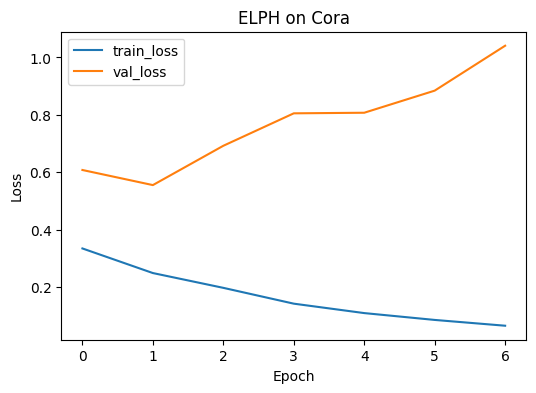

In [72]:
train_metrics = evaluate_split(elph_model, train_data, device, hits_ks=[100])
val_metrics = evaluate_split(elph_model, val_data, device, hits_ks=[100])
test_metrics = evaluate_split(elph_model, test_data, device, hits_ks=[100])

print("Train metrics:", train_metrics)
print("Val metrics:", val_metrics)
print("Test metrics:", test_metrics)

plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train_loss")
if len(history["val_loss"]) > 0:
    plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ELPH on Cora")
plt.legend()
plt.show()

**Bhat Debug**

In [73]:
elph_model_log = ELPH(
    in_channels=train_data.num_features,
    hidden_channels=elph_config["hidden_channels"],
    emb_channels=elph_config["emb_channels"],
    predictor_hidden_channels=elph_config["predictor_hidden_channels"],
    num_hops=elph_config["num_hops"],
    minhash_num_perm=elph_config["minhash_num_perm"],
    hll_p=elph_config["hll_p"],
    dropout=elph_config["dropout"],
    use_log_features=True,
).to(device)

optimizer_log = optim.Adam(
    elph_model_log.parameters(),
    lr=elph_config["lr"],
    weight_decay=elph_config["weight_decay"],
)

history_log = fit(
    model=elph_model_log,
    optimizer=optimizer_log,
    train_data=train_data,
    val_data=val_data,
    device=device,
    epochs=elph_config["epochs"],
    verbose=True,
    patience=elph_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "elph_cora_best_log.pt",
    restore_best_model=True,
)

train_metrics_log = evaluate_split(elph_model_log, train_data, device, hits_ks=[100])
val_metrics_log = evaluate_split(elph_model_log, val_data, device, hits_ks=[100])
test_metrics_log = evaluate_split(elph_model_log, test_data, device, hits_ks=[100])

print("Train metrics (log features):", train_metrics_log)
print("Val metrics (log features):", val_metrics_log)
print("Test metrics (log features):", test_metrics_log)

Training:  73%|███████▎  | 11/15 [00:50<00:18,  4.60s/it, best_val=0.5020, train_loss=0.0890, val_loss=0.6876]


Train metrics (log features): {'loss': 0.2841237187385559, 'auc': 0.9922492111514027, 'ap': 0.9894171974351743, 'hits@100': 0.9556276798248291}
Val metrics (log features): {'loss': 0.5020025968551636, 'auc': 0.836455681617692, 'ap': 0.8553378256402977, 'hits@100': 0.7134724855422974}
Test metrics (log features): {'loss': 0.45290645956993103, 'auc': 0.8827681318928146, 'ap': 0.9017103131902829, 'hits@100': 0.7052132487297058}


#### edge-aware MP ELPH STEPS FUNC TESTING

##### layer_edge_features TESTING

In [47]:
from src.utils.features import build_layer_edge_features

print("edge_batch shape:", edge_batch.shape)
print("num_hops:", num_hops)
print("len(minhash_hops):", len(minhash_hops))
print("len(hll_hops):", len(hll_hops))

edge_batch shape: torch.Size([2, 8])
num_hops: 2
len(minhash_hops): 3
len(hll_hops): 3


In [48]:
layer_features_1 = build_layer_edge_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=1,
    num_hops=num_hops,
    include_b=True,
)

print("layer_features_1 shape:", layer_features_1.shape)
print(layer_features_1)
print("min:", layer_features_1.min().item())
print("max:", layer_features_1.max().item())

layer_features_2 = build_layer_edge_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=2,
    num_hops=num_hops,
    include_b=True,
)

print("layer_features_2 shape:", layer_features_2.shape)
print(layer_features_2)
print("min:", layer_features_2.min().item())
print("max:", layer_features_2.max().item())

layer_features_1 shape: torch.Size([8, 4])
tensor([[0.9902, 0.8959, 1.1316, 1.1316],
        [1.0709, 1.2260, 0.7209, 1.7348],
        [0.7073, 0.8959, 1.4146, 1.4146],
        [1.4202, 0.9430, 0.6545, 2.6863],
        [1.1608, 1.0373, 0.8196, 0.0000],
        [1.0020, 1.0373, 0.9784, 0.0000],
        [0.9430, 1.4202, 2.6863, 0.6545],
        [0.9468, 0.9468, 3.1559, 3.1559]])
min: 0.0
max: 3.1559255123138428
layer_features_2 shape: torch.Size([8, 6])
tensor([[ 0.0000,  2.8004,  0.0000,  1.7736,  0.0000, 67.3918],
        [ 0.0000,  2.4736,  0.0000,  1.2519,  0.3542, 68.5702],
        [ 0.2908,  0.8785,  0.0000,  1.5020,  0.9587,  0.9587],
        [ 0.0000,  3.5999,  0.0000,  2.7596,  0.0000, 64.9184],
        [ 0.0000,  0.7961,  0.0000,  0.0787,  2.1789,  4.0246],
        [ 0.0000,  0.9784,  0.0000,  0.0000,  2.0753,  0.0000],
        [ 0.0000,  2.7596,  0.0000,  3.5999, 64.9184,  0.0000],
        [ 0.0000,  4.2691,  0.0000,  7.6474, 59.3614,  4.9456]])
min: 0.0
max: 68.57018280029297

In [49]:
layer_features_1_no_b = build_layer_edge_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=1,
    num_hops=num_hops,
    include_b=False,
)

layer_features_2_no_b = build_layer_edge_features(
    edge_index=edge_batch,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=2,
    num_hops=num_hops,
    include_b=False,
)

print("layer_features_1_no_b shape:", layer_features_1_no_b.shape)
print(layer_features_1_no_b)

print("\nlayer_features_2_no_b shape:", layer_features_2_no_b.shape)
print(layer_features_2_no_b)

layer_features_1_no_b shape: torch.Size([8, 2])
tensor([[0.9902, 0.8959],
        [1.0709, 1.2260],
        [0.7073, 0.8959],
        [1.4202, 0.9430],
        [1.1608, 1.0373],
        [1.0020, 1.0373],
        [0.9430, 1.4202],
        [0.9468, 0.9468]])

layer_features_2_no_b shape: torch.Size([8, 4])
tensor([[0.0000, 2.8004, 0.0000, 1.7736],
        [0.0000, 2.4736, 0.0000, 1.2519],
        [0.2908, 0.8785, 0.0000, 1.5020],
        [0.0000, 3.5999, 0.0000, 2.7596],
        [0.0000, 0.7961, 0.0000, 0.0787],
        [0.0000, 0.9784, 0.0000, 0.0000],
        [0.0000, 2.7596, 0.0000, 3.5999],
        [0.0000, 4.2691, 0.0000, 7.6474]])


In [50]:
for i in range(edge_batch.size(1)):
    print(f"Edge {i}: {edge_batch[:, i].tolist()}")
    print("Layer 1 features:", layer_features_1[i])
    print("Layer 2 features:", layer_features_2[i])
    print("-" * 60)

Edge 0: [0, 633]
Layer 1 features: tensor([0.9902, 0.8959, 1.1316, 1.1316])
Layer 2 features: tensor([ 0.0000,  2.8004,  0.0000,  1.7736,  0.0000, 67.3918])
------------------------------------------------------------
Edge 1: [0, 1862]
Layer 1 features: tensor([1.0709, 1.2260, 0.7209, 1.7348])
Layer 2 features: tensor([ 0.0000,  2.4736,  0.0000,  1.2519,  0.3542, 68.5702])
------------------------------------------------------------
Edge 2: [0, 2582]
Layer 1 features: tensor([0.7073, 0.8959, 1.4146, 1.4146])
Layer 2 features: tensor([0.2908, 0.8785, 0.0000, 1.5020, 0.9587, 0.9587])
------------------------------------------------------------
Edge 3: [1, 2]
Layer 1 features: tensor([1.4202, 0.9430, 0.6545, 2.6863])
Layer 2 features: tensor([ 0.0000,  3.5999,  0.0000,  2.7596,  0.0000, 64.9184])
------------------------------------------------------------
Edge 4: [1, 652]
Layer 1 features: tensor([1.1608, 1.0373, 0.8196, 0.0000])
Layer 2 features: tensor([0.0000, 0.7961, 0.0000, 0.0787, 

In [51]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch

from src.utils.helpers import set_seed, get_device
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import make_edge_index_undirected
from src.utils.sketches import (
    initialize_minhash,
    initialize_hll,
    propagate_minhash,
    propagate_hll,
)
from src.utils.features import build_layer_edge_features
from src.models.elph import ELPHEdgeAwareLayerLog1p

In [52]:
data = get_data_object(dataset_name, root=project_root / "data")
data = make_edge_index_undirected(data)

x = data.x.to(device)
edge_index = data.edge_index
assert edge_index is not None
edge_index = edge_index.to(device)

print("x shape:", x.shape)
print("edge_index shape:", edge_index.shape)
print(data)

num_nodes = x.size(0)

minhash_0 = initialize_minhash(
    num_nodes=num_nodes,
    num_perm=num_perm,
    base_seed=42,
).to(device)

hll_0 = initialize_hll(
    num_nodes=num_nodes,
    p=hll_p,
    base_seed=42,
).to(device)

minhash_hops = propagate_minhash(
    minhash_sketches=minhash_0,
    edge_index=edge_index,
    num_hops=num_hops,
)

hll_hops = propagate_hll(
    hll_sketches=hll_0,
    edge_index=edge_index,
    num_hops=num_hops,
)

print("Number of MinHash hop tensors:", len(minhash_hops))
print("Number of HLL hop tensors:", len(hll_hops))
print("MinHash hop devices:", [hop.device for hop in minhash_hops])
print("HLL hop devices:", [hop.device for hop in hll_hops])

for i, sketch in enumerate(minhash_hops):
    print(f"MinHash hop {i} shape: {sketch.shape}")

for i, sketch in enumerate(hll_hops):
    print(f"HLL hop {i} shape: {sketch.shape}")

x shape: torch.Size([2708, 1433])
edge_index shape: torch.Size([2, 10556])
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of MinHash hop tensors: 3
Number of HLL hop tensors: 3
MinHash hop devices: [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
HLL hop devices: [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
MinHash hop 0 shape: torch.Size([2708, 64])
MinHash hop 1 shape: torch.Size([2708, 64])
MinHash hop 2 shape: torch.Size([2708, 64])
HLL hop 0 shape: torch.Size([2708, 256])
HLL hop 1 shape: torch.Size([2708, 256])
HLL hop 2 shape: torch.Size([2708, 256])


In [53]:
layer_idx = 1

layer_edge_features_1 = build_layer_edge_features(
    edge_index=edge_index,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=layer_idx,
    num_hops=num_hops,
    include_b=True,
)

print("layer_edge_features_1 shape:", layer_edge_features_1.shape)
print("min:", layer_edge_features_1.min().item())
print("max:", layer_edge_features_1.max().item())
print(layer_edge_features_1[:5])

layer_edge_features_1 shape: torch.Size([10556, 4])
min: 0.0
max: 179.120849609375
tensor([[0.9902, 0.8959, 1.1316, 1.1316],
        [1.0709, 1.2260, 0.7209, 1.7348],
        [0.7073, 0.8959, 1.4146, 1.4146],
        [1.4202, 0.9430, 0.6545, 2.6863],
        [1.1608, 1.0373, 0.8196, 0.0000]], device='cuda:0')


In [54]:
edge_aware_layer_1 = ELPHEdgeAwareLayerLog1p(
    node_channels=x.size(1),
    edge_feature_dim=layer_edge_features_1.size(1),
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
    use_log_edge_features=False
).to(device)

edge_aware_layer_1.eval()

with torch.no_grad():
    updated_x_1 = edge_aware_layer_1(
        x=x,
        edge_index=edge_index,
        edge_features=layer_edge_features_1,
    )

print("updated_x_1 shape:", updated_x_1.shape)
print("min:", updated_x_1.min().item())
print("max:", updated_x_1.max().item())
print(updated_x_1[:3, :8])

updated_x_1 shape: torch.Size([2708, 1433])
min: -71.8371810913086
max: 57.80347442626953
tensor([[ 0.1929, -0.0758, -0.1472,  0.0168,  0.1669,  0.0509,  0.0237, -0.0190],
        [ 0.2063, -0.0791, -0.0962, -0.0308,  0.1819,  0.0486,  0.0880, -0.0172],
        [ 0.2473, -0.0431, -0.1098,  0.0077,  0.2721,  0.1519,  0.0003,  0.0043]],
       device='cuda:0')


In [55]:
layer_idx = 2

layer_edge_features_2 = build_layer_edge_features(
    edge_index=edge_index,
    minhash_hops=minhash_hops,
    hll_hops=hll_hops,
    layer_idx=layer_idx,
    num_hops=num_hops,
    include_b=True,
)

print("layer_edge_features_2 shape:", layer_edge_features_2.shape)
print("min:", layer_edge_features_2.min().item())
print("max:", layer_edge_features_2.max().item())
print(layer_edge_features_2[:5])

layer_edge_features_2 shape: torch.Size([10556, 6])
min: 0.0
max: 669.1486206054688
tensor([[ 0.0000,  2.8004,  0.0000,  1.7736,  0.0000, 67.3918],
        [ 0.0000,  2.4736,  0.0000,  1.2519,  0.3542, 68.5702],
        [ 0.2908,  0.8785,  0.0000,  1.5020,  0.9587,  0.9587],
        [ 0.0000,  3.5999,  0.0000,  2.7596,  0.0000, 64.9184],
        [ 0.0000,  0.7961,  0.0000,  0.0787,  2.1789,  4.0246]],
       device='cuda:0')


In [56]:
edge_aware_layer_2 = ELPHEdgeAwareLayerLog1p(
    node_channels=updated_x_1.size(1),
    edge_feature_dim=layer_edge_features_2.size(1),
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
    use_log_edge_features=False
).to(device)

edge_aware_layer_2.eval()

with torch.no_grad():
    updated_x_2 = edge_aware_layer_2(
        x=updated_x_1,
        edge_index=edge_index,
        edge_features=layer_edge_features_2,
    )

print("updated_x_2 shape:", updated_x_2.shape)
print("min:", updated_x_2.min().item())
print("max:", updated_x_2.max().item())
print(updated_x_2[:3, :8])

updated_x_2 shape: torch.Size([2708, 1433])
min: -539.7618408203125
max: 415.7300720214844
tensor([[ 0.2699, -0.3176,  0.1258,  0.2399, -0.1180,  0.0240,  0.0918,  0.1683],
        [ 0.2089, -0.2238,  0.1136,  0.2000, -0.0846,  0.0897,  0.0403,  0.1242],
        [ 0.5584, -0.3111, -0.0231,  0.2867, -0.2549,  0.1130, -0.0803,  0.2445]],
       device='cuda:0')


In [57]:
edge_aware_layer_1 = ELPHEdgeAwareLayerLog1p(
    node_channels=x.size(1),
    edge_feature_dim=layer_edge_features_1.size(1),
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
    use_log_edge_features=True,
).to(device)

edge_aware_layer_1.eval()

with torch.no_grad():
    updated_x_1 = edge_aware_layer_1(
        x=x,
        edge_index=edge_index,
        edge_features=layer_edge_features_1,
    )

print("updated_x_1 shape:", updated_x_1.shape)
print("min:", updated_x_1.min().item())
print("max:", updated_x_1.max().item())
print(updated_x_1[:3, :8])

edge_aware_layer_2 = ELPHEdgeAwareLayerLog1p(
    node_channels=updated_x_1.size(1),
    edge_feature_dim=layer_edge_features_2.size(1),
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
    use_log_edge_features=True,
).to(device)

edge_aware_layer_2.eval()

with torch.no_grad():
    updated_x_2 = edge_aware_layer_2(
        x=updated_x_1,
        edge_index=edge_index,
        edge_features=layer_edge_features_2,
    )

print("updated_x_2 shape:", updated_x_2.shape)
print("min:", updated_x_2.min().item())
print("max:", updated_x_2.max().item())
print(updated_x_2[:3, :8])

updated_x_1 shape: torch.Size([2708, 1433])
min: -6.637678623199463
max: 6.7254509925842285
tensor([[-0.0108, -0.0098, -0.1089,  0.0361,  0.0848,  0.0680,  0.0021,  0.1450],
        [-0.0575, -0.0125, -0.1024,  0.0230,  0.1067,  0.0667, -0.0452,  0.1447],
        [ 0.0139, -0.0025, -0.1036,  0.0190,  0.1176,  0.0619, -0.0516,  0.1389]],
       device='cuda:0')
updated_x_2 shape: torch.Size([2708, 1433])
min: -30.862693786621094
max: 31.51972198486328
tensor([[ 0.0894,  0.0140,  0.0121,  0.0256, -0.0498,  0.1132, -0.1290,  0.0801],
        [ 0.0941,  0.0149,  0.0149,  0.0274, -0.0434,  0.1138, -0.1366,  0.0788],
        [ 0.1224, -0.0040, -0.0444,  0.0381, -0.0763,  0.1675, -0.1498,  0.0626]],
       device='cuda:0')


##### ELPHEdgeAwareLayerLog1p Encoder TESTING

In [58]:
from src.models.elph import ELPHEdgeAwareEncoder

In [59]:
edge_aware_encoder = ELPHEdgeAwareEncoder(
    in_channels=x.size(1),
    hidden_channels=64,
    num_hops=2,
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
).to(device)

print(edge_aware_encoder)

ELPHEdgeAwareEncoder(
  (input_proj): Linear(in_features=1433, out_features=64, bias=True)
  (layers): ModuleList(
    (0): ELPHEdgeAwareLayerLog1p(
      (message_mlp): Sequential(
        (0): Linear(in_features=132, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=64, out_features=64, bias=True)
      )
      (update_mlp): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=64, out_features=64, bias=True)
      )
    )
    (1): ELPHEdgeAwareLayerLog1p(
      (message_mlp): Sequential(
        (0): Linear(in_features=134, out_features=64, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=64, out_features=64, bias=True)
      )
      (update_mlp): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReL

In [60]:
edge_aware_encoder.eval()

with torch.no_grad():
    z_edge_aware = edge_aware_encoder(
        x=x,
        edge_index=edge_index,
        minhash_hops=minhash_hops,
        hll_hops=hll_hops,
    )

print("z_edge_aware shape:", z_edge_aware.shape)
print("min:", z_edge_aware.min().item())
print("max:", z_edge_aware.max().item())
print(z_edge_aware[:3, :8])

z_edge_aware shape: torch.Size([2708, 64])
min: -42.102806091308594
max: 44.37943649291992
tensor([[ 0.0295,  0.0094,  0.1069, -0.0825, -0.0521, -0.0279, -0.1359, -0.0261],
        [ 0.0292,  0.0065,  0.1019, -0.0984, -0.0496, -0.0176, -0.1198, -0.0416],
        [-0.0249, -0.0915, -0.0047, -0.3072, -0.0086, -0.0220, -0.1000,  0.0177]],
       device='cuda:0')


#### FUll edge-aware MP on Cora

In [61]:
from src.models.elph import ELPHEdgeAware

In [62]:
edge_aware_elph = ELPHEdgeAware(
    in_channels=x.size(1),
    hidden_channels=64,
    predictor_hidden_channels=64,
    num_hops=2,
    minhash_num_perm=128,
    hll_p=8,
    message_hidden_channels=64,
    update_hidden_channels=64,
    dropout=0.2,
    use_log_features=False,
).to(device)

print(edge_aware_elph)

ELPHEdgeAware(
  (encoder): ELPHEdgeAwareEncoder(
    (input_proj): Linear(in_features=1433, out_features=64, bias=True)
    (layers): ModuleList(
      (0): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=132, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (1): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=134, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
     

In [64]:
edge_label_index_batch = edge_index[:, :16]

edge_aware_elph.eval()

with torch.no_grad():
    logits_edge_aware = edge_aware_elph(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index_batch,
    )

print("logits_edge_aware shape:", logits_edge_aware.shape)
print("min:", logits_edge_aware.min().item())
print("max:", logits_edge_aware.max().item())
print(logits_edge_aware)

logits_edge_aware shape: torch.Size([16])
min: -0.9432476162910461
max: 1.2654590606689453
tensor([ 0.5327,  0.5196,  0.0437,  0.5066,  0.0732,  0.0338,  0.6008,  0.6129,
         0.6202,  0.5600, -0.9432,  0.0168,  0.0312,  0.0582,  1.2655,  0.0854],
       device='cuda:0')


In [65]:
edge_aware_elph.eval()

with torch.no_grad():
    minhash_hops_test, hll_hops_test = edge_aware_elph.build_sketch_hops(
        num_nodes=x.size(0),
        edge_index=edge_index,
    )

    z_edge_aware_full = edge_aware_elph.encode(
        x=x,
        edge_index=edge_index,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )

    structural_features_test = edge_aware_elph.build_full_structural_features(
        edge_label_index=edge_label_index_batch,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )

    logits_decode = edge_aware_elph.decode(
        z=z_edge_aware_full,
        edge_label_index=edge_label_index_batch,
        structural_features=structural_features_test,
    )

print("z_edge_aware_full shape:", z_edge_aware_full.shape)
print("structural_features_test shape:", structural_features_test.shape)
print("logits_decode shape:", logits_decode.shape)
print(logits_decode)

z_edge_aware_full shape: torch.Size([2708, 64])
structural_features_test shape: torch.Size([16, 13])
logits_decode shape: torch.Size([16])
tensor([ 0.5327,  0.5196,  0.0437,  0.5066,  0.0732,  0.0338,  0.6008,  0.6129,
         0.6202,  0.5600, -0.9432,  0.0168,  0.0312,  0.0582,  1.2655,  0.0854],
       device='cuda:0')


In [66]:
edge_aware_elph.eval()

with torch.no_grad():
    logits_forward = edge_aware_elph(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index_batch,
    )

    minhash_hops_test, hll_hops_test = edge_aware_elph.build_sketch_hops(
        num_nodes=x.size(0),
        edge_index=edge_index,
    )

    z_edge_aware_full = edge_aware_elph.encode(
        x=x,
        edge_index=edge_index,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )

    structural_features_test = edge_aware_elph.build_full_structural_features(
        edge_label_index=edge_label_index_batch,
        minhash_hops=minhash_hops_test,
        hll_hops=hll_hops_test,
    )

    logits_decode = edge_aware_elph.decode(
        z=z_edge_aware_full,
        edge_label_index=edge_label_index_batch,
        structural_features=structural_features_test,
    )

max_diff = torch.max(torch.abs(logits_forward - logits_decode)).item()

print("Max absolute difference:", max_diff)
print("Forward logits:", logits_forward)
print("Decode logits :", logits_decode)

Max absolute difference: 2.384185791015625e-07
Forward logits: tensor([ 0.5327,  0.5196,  0.0437,  0.5066,  0.0732,  0.0338,  0.6008,  0.6129,
         0.6202,  0.5600, -0.9432,  0.0168,  0.0312,  0.0582,  1.2655,  0.0854],
       device='cuda:0')
Decode logits : tensor([ 0.5327,  0.5196,  0.0437,  0.5066,  0.0732,  0.0338,  0.6008,  0.6129,
         0.6202,  0.5600, -0.9432,  0.0168,  0.0312,  0.0582,  1.2655,  0.0854],
       device='cuda:0')


**FOLLOWING CONTENT WILL DISCUSS THE NECESSITY OF Log1p FOR MODEL LEVEL**

In [68]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

edge_aware_config = {
    "hidden_channels": 64,
    "predictor_hidden_channels": 64,
    "num_hops": 2,
    "minhash_num_perm": 128,
    "hll_p": 8,
    "message_hidden_channels": 64,
    "update_hidden_channels": 64,
    "dropout": 0.2,
    "lr": 1e-2,
    "weight_decay": 1e-4,
    "epochs": 15,
    "patience": 5,
}

print("Device:", device)
print("Dataset:", dataset_name)
print(edge_aware_config)

data = get_data_object(dataset_name, root=project_root / "data")
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print("Train split summary:")
print(summarize_split(train_data))

print("\nVal split summary:")
print(summarize_split(val_data))

print("\nTest split summary:")
print(summarize_split(test_data))

Device: cuda
Dataset: Cora
{'hidden_channels': 64, 'predictor_hidden_channels': 64, 'num_hops': 2, 'minhash_num_perm': 128, 'hll_p': 8, 'message_hidden_channels': 64, 'update_hidden_channels': 64, 'dropout': 0.2, 'lr': 0.01, 'weight_decay': 0.0001, 'epochs': 15, 'patience': 5}
Train split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 7392), 'edge_label_shape': (7392,), 'num_positive_labels': 3696, 'num_negative_labels': 3696}

Val split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 7392), 'edge_label_index_shape': (2, 1054), 'edge_label_shape': (1054,), 'num_positive_labels': 527, 'num_negative_labels': 527}

Test split summary:
{'num_nodes': 2708, 'num_features': 1433, 'edge_index_shape': (2, 8446), 'edge_label_index_shape': (2, 2110), 'edge_label_shape': (2110,), 'num_positive_labels': 1055, 'num_negative_labels': 1055}


In [70]:
edge_aware_model_plain = ELPHEdgeAware(
    in_channels=train_data.num_features,
    hidden_channels=edge_aware_config["hidden_channels"],
    predictor_hidden_channels=edge_aware_config["predictor_hidden_channels"],
    num_hops=edge_aware_config["num_hops"],
    minhash_num_perm=edge_aware_config["minhash_num_perm"],
    hll_p=edge_aware_config["hll_p"],
    message_hidden_channels=edge_aware_config["message_hidden_channels"],
    update_hidden_channels=edge_aware_config["update_hidden_channels"],
    dropout=edge_aware_config["dropout"],
    use_log_features=False,
).to(device)

optimizer_plain = optim.Adam(
    edge_aware_model_plain.parameters(),
    lr=edge_aware_config["lr"],
    weight_decay=edge_aware_config["weight_decay"],
)

print(edge_aware_model_plain)
print("Trainable parameters:", count_parameters(edge_aware_model_plain))

edge_aware_model_plain.eval()

x = train_data.x.to(device)
edge_index = train_data.edge_index.to(device)
edge_label_index = train_data.edge_label_index[:, :16].to(device)

with torch.no_grad():
    logits_plain = edge_aware_model_plain(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index,
    )

print("logits_plain shape:", logits_plain.shape)
print(logits_plain)

ELPHEdgeAware(
  (encoder): ELPHEdgeAwareEncoder(
    (input_proj): Linear(in_features=1433, out_features=64, bias=True)
    (layers): ModuleList(
      (0): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=132, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (1): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=134, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
     

In [71]:
history_plain = fit(
    model=edge_aware_model_plain,
    optimizer=optimizer_plain,
    train_data=train_data,
    val_data=val_data,
    device=device,
    epochs=edge_aware_config["epochs"],
    verbose=True,
    patience=edge_aware_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "elph_edge_aware_cora_plain_best.pt",
    restore_best_model=True,
)

print("Training finished (plain).")
print("Best epoch:", history_plain["best_epoch"])
print("Best val loss:", history_plain["best_val_loss"])
print("Epochs ran:", history_plain["epochs_ran"])
print("Stopped early:", history_plain["stopped_early"])

Training:  87%|████████▋ | 13/15 [00:54<00:08,  4.23s/it, best_val=0.6011, train_loss=0.2855, val_loss=0.6808]

Training finished (plain).
Best epoch: 9
Best val loss: 0.6010938882827759
Epochs ran: 14
Stopped early: True


Train metrics (plain): {'loss': 0.3950597047805786, 'auc': 0.9823965097402598, 'ap': 0.9787880142366776, 'hits@100': 0.9521104097366333}
Val metrics (plain): {'loss': 0.6010938882827759, 'auc': 0.7732645852611719, 'ap': 0.7978347221735429, 'hits@100': 0.6204933524131775}
Test metrics (plain): {'loss': 0.5559478998184204, 'auc': 0.8192502414590868, 'ap': 0.8540416802317834, 'hits@100': 0.5990521311759949}


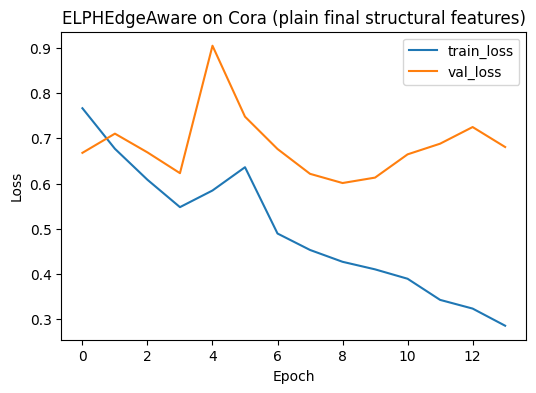

In [72]:
train_metrics_plain = evaluate_split(edge_aware_model_plain, train_data, device, hits_ks=[100])
val_metrics_plain = evaluate_split(edge_aware_model_plain, val_data, device, hits_ks=[100])
test_metrics_plain = evaluate_split(edge_aware_model_plain, test_data, device, hits_ks=[100])

print("Train metrics (plain):", train_metrics_plain)
print("Val metrics (plain):", val_metrics_plain)
print("Test metrics (plain):", test_metrics_plain)

plt.figure(figsize=(6, 4))
plt.plot(history_plain["train_loss"], label="train_loss")
if len(history_plain["val_loss"]) > 0:
    plt.plot(history_plain["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ELPHEdgeAware on Cora (plain final structural features)")
plt.legend()
plt.show()

In [73]:
set_seed(42)

edge_aware_model_log = ELPHEdgeAware(
    in_channels=train_data.num_features,
    hidden_channels=edge_aware_config["hidden_channels"],
    predictor_hidden_channels=edge_aware_config["predictor_hidden_channels"],
    num_hops=edge_aware_config["num_hops"],
    minhash_num_perm=edge_aware_config["minhash_num_perm"],
    hll_p=edge_aware_config["hll_p"],
    message_hidden_channels=edge_aware_config["message_hidden_channels"],
    update_hidden_channels=edge_aware_config["update_hidden_channels"],
    dropout=edge_aware_config["dropout"],
    use_log_features=True, # <------
).to(device)

optimizer_log = optim.Adam(
    edge_aware_model_log.parameters(),
    lr=edge_aware_config["lr"],
    weight_decay=edge_aware_config["weight_decay"],
)

print(edge_aware_model_log)
print("Trainable parameters:", count_parameters(edge_aware_model_log))

edge_aware_model_log.eval()

with torch.no_grad():
    logits_log = edge_aware_model_log(
        x=x,
        edge_index=edge_index,
        edge_label_index=edge_label_index,
    )

print("logits_log shape:", logits_log.shape)
print(logits_log)

ELPHEdgeAware(
  (encoder): ELPHEdgeAwareEncoder(
    (input_proj): Linear(in_features=1433, out_features=64, bias=True)
    (layers): ModuleList(
      (0): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=132, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (1): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=134, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
     

In [74]:
history_log = fit(
    model=edge_aware_model_log,
    optimizer=optimizer_log,
    train_data=train_data,
    val_data=val_data,
    device=device,
    epochs=edge_aware_config["epochs"],
    verbose=True,
    patience=edge_aware_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "elph_edge_aware_cora_log_best.pt",
    restore_best_model=True,
)

print("Training finished (log final features).")
print("Best epoch:", history_log["best_epoch"])
print("Best val loss:", history_log["best_val_loss"])
print("Epochs ran:", history_log["epochs_ran"])
print("Stopped early:", history_log["stopped_early"])

Training: 100%|██████████| 15/15 [01:01<00:00,  4.08s/it, best_val=0.5239, train_loss=0.2483, val_loss=0.5741]

Training finished (log final features).
Best epoch: 11
Best val loss: 0.5239141583442688
Epochs ran: 15
Stopped early: False


Train metrics (log final features): {'loss': 0.3283945322036743, 'auc': 0.9831812589016323, 'ap': 0.9748642737346768, 'hits@100': 0.7851731777191162}
Val metrics (log final features): {'loss': 0.5239141583442688, 'auc': 0.8238642705659114, 'ap': 0.8458955802350172, 'hits@100': 0.7096773982048035}
Test metrics (log final features): {'loss': 0.49625810980796814, 'auc': 0.8497643808539791, 'ap': 0.8644313077423115, 'hits@100': 0.6654028296470642}


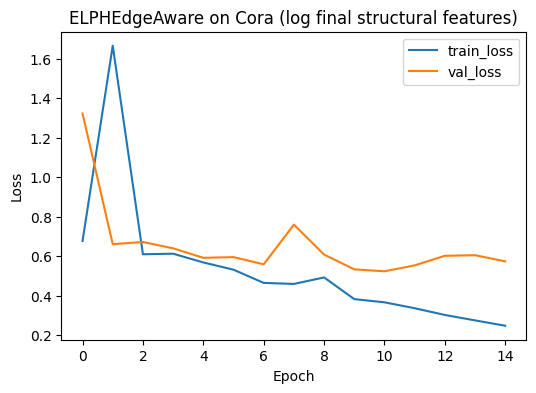

In [75]:
train_metrics_log = evaluate_split(edge_aware_model_log, train_data, device, hits_ks=[100])
val_metrics_log = evaluate_split(edge_aware_model_log, val_data, device, hits_ks=[100])
test_metrics_log = evaluate_split(edge_aware_model_log, test_data, device, hits_ks=[100])

print("Train metrics (log final features):", train_metrics_log)
print("Val metrics (log final features):", val_metrics_log)
print("Test metrics (log final features):", test_metrics_log)

plt.figure(figsize=(6, 4))
plt.plot(history_log["train_loss"], label="train_loss")
if len(history_log["val_loss"]) > 0:
    plt.plot(history_log["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ELPHEdgeAware on Cora (log final structural features)")
plt.legend()
plt.show()

In [76]:
print("Plain final structural features:")
print("Best epoch:", history_plain["best_epoch"])
print("Best val loss:", history_plain["best_val_loss"])
print("Train:", train_metrics_plain)
print("Val  :", val_metrics_plain)
print("Test :", test_metrics_plain)

print("\nLog-scaled final structural features:")
print("Best epoch:", history_log["best_epoch"])
print("Best val loss:", history_log["best_val_loss"])
print("Train:", train_metrics_log)
print("Val  :", val_metrics_log)
print("Test :", test_metrics_log)

Plain final structural features:
Best epoch: 9
Best val loss: 0.6010938882827759
Train: {'loss': 0.3950597047805786, 'auc': 0.9823965097402598, 'ap': 0.9787880142366776, 'hits@100': 0.9521104097366333}
Val  : {'loss': 0.6010938882827759, 'auc': 0.7732645852611719, 'ap': 0.7978347221735429, 'hits@100': 0.6204933524131775}
Test : {'loss': 0.5559478998184204, 'auc': 0.8192502414590868, 'ap': 0.8540416802317834, 'hits@100': 0.5990521311759949}

Log-scaled final structural features:
Best epoch: 11
Best val loss: 0.5239141583442688
Train: {'loss': 0.3283945322036743, 'auc': 0.9831812589016323, 'ap': 0.9748642737346768, 'hits@100': 0.7851731777191162}
Val  : {'loss': 0.5239141583442688, 'auc': 0.8238642705659114, 'ap': 0.8458955802350172, 'hits@100': 0.7096773982048035}
Test : {'loss': 0.49625810980796814, 'auc': 0.8497643808539791, 'ap': 0.8644313077423115, 'hits@100': 0.6654028296470642}


FOR SURE USING Log1p METHOD.

## BUDDY CHECKING

### PREPROCESSING TESTING

In [9]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch

from src.utils.helpers import set_seed, get_device
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import make_edge_index_undirected
from src.utils.buddy_helpers import (
    build_buddy_cache,
    build_buddy_edge_features_from_cache,
)

In [10]:
set_seed(42)
device = get_device()

dataset_name = "Cora"
num_hops = 2
minhash_num_perm = 128
hll_p = 8

print("Device:", device)
print("Dataset:", dataset_name)
print("num_hops:", num_hops)
print("minhash_num_perm:", minhash_num_perm)
print("hll_p:", hll_p)

data = get_data_object(dataset_name, root=project_root / "data")
data = make_edge_index_undirected(data)

x = data.x.to(device)
edge_index = data.edge_index
assert edge_index is not None
edge_index = edge_index.to(device)

print("x shape:", x.shape)
print("edge_index shape:", edge_index.shape)
print(data)

Device: cuda
Dataset: Cora
num_hops: 2
minhash_num_perm: 128
hll_p: 8
x shape: torch.Size([2708, 1433])
edge_index shape: torch.Size([2, 10556])
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [11]:
buddy_cache = build_buddy_cache(
    x=x,
    edge_index=edge_index,
    num_hops=num_hops,
    minhash_num_perm=minhash_num_perm,
    hll_p=hll_p,
    feature_propagation="mean",
    cache_device=device,
)

print("Cache keys:", buddy_cache.keys())
print("num_nodes:", buddy_cache["num_nodes"])
print("num_hops :", buddy_cache["num_hops"])

Cache keys: dict_keys(['num_nodes', 'num_hops', 'propagated_x_hops', 'minhash_hops', 'hll_hops', 'cardinality_hops'])
num_nodes: 2708
num_hops : 2


In [12]:
propagated_x_hops = buddy_cache["propagated_x_hops"]

print("Number of propagated_x_hops:", len(propagated_x_hops))
for i, tensor in enumerate(propagated_x_hops):
    print(
        f"propagated_x_hops[{i}] shape: {tensor.shape}, "
        f"device: {tensor.device}, min: {tensor.min().item():.4f}, max: {tensor.max().item():.4f}"
    )

Number of propagated_x_hops: 3
propagated_x_hops[0] shape: torch.Size([2708, 1433]), device: cuda:0, min: 0.0000, max: 1.0000
propagated_x_hops[1] shape: torch.Size([2708, 1433]), device: cuda:0, min: 0.0000, max: 1.0000
propagated_x_hops[2] shape: torch.Size([2708, 1433]), device: cuda:0, min: 0.0000, max: 1.0000


In [13]:
hll_hops = buddy_cache["hll_hops"]

print("Number of hll_hops:", len(hll_hops))
for i, tensor in enumerate(hll_hops):
    print(
        f"hll_hops[{i}] shape: {tensor.shape}, "
        f"device: {tensor.device}"
    )

Number of hll_hops: 3
hll_hops[0] shape: torch.Size([2708, 256]), device: cuda:0
hll_hops[1] shape: torch.Size([2708, 256]), device: cuda:0
hll_hops[2] shape: torch.Size([2708, 256]), device: cuda:0


In [17]:
minhash_hops = buddy_cache["minhash_hops"]

print("Number of minhash_hops:", len(minhash_hops))
for i, tensor in enumerate(minhash_hops):
    print(
        f"minhash_hops[{i}] shape: {tensor.shape}, "
        f"device: {tensor.device}"
    )

Number of minhash_hops: 3
minhash_hops[0] shape: torch.Size([2708, 128]), device: cuda:0
minhash_hops[1] shape: torch.Size([2708, 128]), device: cuda:0
minhash_hops[2] shape: torch.Size([2708, 128]), device: cuda:0


In [18]:
cardinality_hops = buddy_cache["cardinality_hops"]

print("Number of cardinality_hops:", len(cardinality_hops))
for i, tensor in enumerate(cardinality_hops):
    print(
        f"cardinality_hops[{i}] shape: {tensor.shape}, "
        f"device: {tensor.device}, "
        f"min: {tensor.min().item():.4f}, max: {tensor.max().item():.4f}"
    )

print("\nFirst 5 values of each cardinality hop:")
for i, tensor in enumerate(cardinality_hops):
    print(f"Hop {i}: {tensor[:5]}")

Number of cardinality_hops: 3
cardinality_hops[0] shape: torch.Size([2708]), device: cuda:0, min: 1.0020, max: 1.0020
cardinality_hops[1] shape: torch.Size([2708]), device: cuda:0, min: 1.0020, max: 179.4535
cardinality_hops[2] shape: torch.Size([2708]), device: cuda:0, min: 1.0020, max: 1092.0179

First 5 values of each cardinality hop:
Hop 0: tensor([1.0020, 1.0020, 1.0020, 1.0020, 1.0020], device='cuda:0')
Hop 1: tensor([3.0177, 3.0177, 5.0495, 1.0020, 5.0495], device='cuda:0')
Hop 2: tensor([ 7.0975,  6.0714, 76.3273,  1.0020, 14.3974], device='cuda:0')


In [19]:
for hop_idx in range(len(propagated_x_hops)):
    print(f"\n--- propagated_x_hops[{hop_idx}] first 3 nodes, first 8 dims ---")
    print(propagated_x_hops[hop_idx][:3, :8])


--- propagated_x_hops[0] first 3 nodes, first 8 dims ---
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

--- propagated_x_hops[1] first 3 nodes, first 8 dims ---
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3333, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2000, 0.0000]],
       device='cuda:0')

--- propagated_x_hops[2] first 3 nodes, first 8 dims ---
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0667, 0.0000],
        [0.0000, 0.0031, 0.0092, 0.0000, 0.0667, 0.0333, 0.0031, 0.0000]],
       device='cuda:0')


In [20]:
print("propagated_x_hops devices:", [tensor.device for tensor in propagated_x_hops])
print("minhash_hops devices     :", [tensor.device for tensor in minhash_hops])
print("hll_hops devices         :", [tensor.device for tensor in hll_hops])
print("cardinality_hops devices :", [tensor.device for tensor in cardinality_hops])

propagated_x_hops devices: [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
minhash_hops devices     : [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
hll_hops devices         : [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
cardinality_hops devices : [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]


In [21]:
edge_label_index_batch = edge_index[:, :16]

print("edge_label_index_batch shape:", edge_label_index_batch.shape)
print(edge_label_index_batch)

edge_label_index_batch shape: torch.Size([2, 16])
tensor([[   0,    0,    0,    1,    1,    1,    2,    2,    2,    2,    2,    3,
            4,    4,    4,    4],
        [ 633, 1862, 2582,    2,  652,  654,    1,  332, 1454, 1666, 1986, 2544,
         1016, 1256, 1761, 2175]], device='cuda:0')


In [22]:
buddy_edge_inputs_plain = build_buddy_edge_features_from_cache(
    buddy_cache=buddy_cache,
    edge_label_index=edge_label_index_batch,
    structural_use_log=False,
)

print("Returned keys:", buddy_edge_inputs_plain.keys())

Returned keys: dict_keys(['edge_label_index', 'src_features', 'dst_features', 'pair_features', 'structural_features'])


In [23]:
src_features_plain = buddy_edge_inputs_plain["src_features"]
dst_features_plain = buddy_edge_inputs_plain["dst_features"]
pair_features_plain = buddy_edge_inputs_plain["pair_features"]
structural_features_plain = buddy_edge_inputs_plain["structural_features"]

print("src_features_plain shape:", src_features_plain.shape)
print("dst_features_plain shape:", dst_features_plain.shape)
print("pair_features_plain shape:", pair_features_plain.shape)
print("structural_features_plain shape:", structural_features_plain.shape)

print("\nsrc min/max:", src_features_plain.min().item(), src_features_plain.max().item())
print("dst min/max:", dst_features_plain.min().item(), dst_features_plain.max().item())
print("pair min/max:", pair_features_plain.min().item(), pair_features_plain.max().item())
print("structural min/max:", structural_features_plain.min().item(), structural_features_plain.max().item())

src_features_plain shape: torch.Size([16, 1433])
dst_features_plain shape: torch.Size([16, 1433])
pair_features_plain shape: torch.Size([16, 5732])
structural_features_plain shape: torch.Size([16, 13])

src min/max: 0.0 1.0
dst min/max: 0.0 1.0
pair min/max: 0.0 1.0
structural min/max: 0.0 171.30125427246094


In [24]:
print("First 2 src feature rows (first 8 dims):")
print(src_features_plain[:2, :8])

print("\nFirst 2 dst feature rows (first 8 dims):")
print(dst_features_plain[:2, :8])

print("\nFirst 2 pair feature rows (first 8 dims):")
print(pair_features_plain[:2, :8])

print("\nFirst 2 structural feature rows:")
print(structural_features_plain[:2])

First 2 src feature rows (first 8 dims):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

First 2 dst feature rows (first 8 dims):
tensor([[0.0045, 0.0090, 0.0180, 0.0090, 0.0000, 0.0000, 0.0045, 0.0000],
        [0.0034, 0.0068, 0.0135, 0.0068, 0.0000, 0.0000, 0.0034, 0.0000]],
       device='cuda:0')

First 2 pair feature rows (first 8 dims):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')

First 2 structural feature rows:
tensor([[ 0.0000,  1.1081,  0.0000,  1.1316,  0.0000,  2.4467,  0.0000,  0.9209,
          0.0000,  0.7780,  0.7121,  0.7780, 68.5981],
        [ 0.0000,  1.1339,  0.0000,  1.0373,  0.0000,  2.5992,  0.0716,  1.7495,
          0.2006,  0.8465,  0.0000,  1.8604, 67.6747]], device='cuda:0')


In [25]:
buddy_edge_inputs_log = build_buddy_edge_features_from_cache(
    buddy_cache=buddy_cache,
    edge_label_index=edge_label_index_batch,
    structural_use_log=True,
)

print("Returned keys:", buddy_edge_inputs_log.keys())

Returned keys: dict_keys(['edge_label_index', 'src_features', 'dst_features', 'pair_features', 'structural_features'])


In [26]:
structural_features_log = buddy_edge_inputs_log["structural_features"]

print("structural_features_log shape:", structural_features_log.shape)
print("plain structural min/max:", structural_features_plain.min().item(), structural_features_plain.max().item())
print("log structural min/max  :", structural_features_log.min().item(), structural_features_log.max().item())

print("\nFirst 2 plain structural feature rows:")
print(structural_features_plain[:2])

print("\nFirst 2 log structural feature rows:")
print(structural_features_log[:2])

structural_features_log shape: torch.Size([16, 13])
plain structural min/max: 0.0 171.30125427246094
log structural min/max  : 0.0 5.14924430847168

First 2 plain structural feature rows:
tensor([[ 0.0000,  1.1081,  0.0000,  1.1316,  0.0000,  2.4467,  0.0000,  0.9209,
          0.0000,  0.7780,  0.7121,  0.7780, 68.5981],
        [ 0.0000,  1.1339,  0.0000,  1.0373,  0.0000,  2.5992,  0.0716,  1.7495,
          0.2006,  0.8465,  0.0000,  1.8604, 67.6747]], device='cuda:0')

First 2 log structural feature rows:
tensor([[0.0000, 0.7458, 0.0000, 0.7569, 0.0000, 1.2374, 0.0000, 0.6528, 0.0000,
         0.5755, 0.5377, 0.5755, 4.2427],
        [0.0000, 0.7579, 0.0000, 0.7116, 0.0000, 1.2807, 0.0692, 1.0114, 0.1828,
         0.6133, 0.0000, 1.0509, 4.2294]], device='cuda:0')


In [27]:
i = 0

src_row = src_features_plain[i]
dst_row = dst_features_plain[i]
pair_row = pair_features_plain[i]

d = src_row.size(0)

src_from_pair = pair_row[:d]
dst_from_pair = pair_row[d:2*d]
hadamard_from_pair = pair_row[2*d:3*d]
absdiff_from_pair = pair_row[3*d:4*d]

print("src matches:", torch.allclose(src_row, src_from_pair))
print("dst matches:", torch.allclose(dst_row, dst_from_pair))
print("hadamard matches:", torch.allclose(src_row * dst_row, hadamard_from_pair))
print("abs diff matches:", torch.allclose(torch.abs(src_row - dst_row), absdiff_from_pair))

src matches: True
dst matches: True
hadamard matches: True
abs diff matches: True


### STEP FUNC TESTING

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch

from src.utils.helpers import set_seed, get_device
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import make_edge_index_undirected
from src.utils.buddy_helpers import build_buddy_cache
from src.models.buddy import BUDDY

In [2]:
set_seed(42)
device = get_device()

dataset_name = "Cora"
num_hops = 2
minhash_num_perm = 128
hll_p = 8

print("Device:", device)
print("Dataset:", dataset_name)
print("num_hops:", num_hops)
print("minhash_num_perm:", minhash_num_perm)
print("hll_p:", hll_p)

data = get_data_object(dataset_name, root=project_root / "data")
data = make_edge_index_undirected(data)

x = data.x.to(device)
edge_index = data.edge_index
assert edge_index is not None
edge_index = edge_index.to(device)

print("x shape:", x.shape)
print("edge_index shape:", edge_index.shape)
print(data)

Device: cuda
Dataset: Cora
num_hops: 2
minhash_num_perm: 128
hll_p: 8
x shape: torch.Size([2708, 1433])
edge_index shape: torch.Size([2, 10556])
Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [3]:
buddy_cache = build_buddy_cache(
    x=x,
    edge_index=edge_index,
    num_hops=num_hops,
    minhash_num_perm=minhash_num_perm,
    hll_p=hll_p,
    feature_propagation="mean",
    cache_device=device,
)

print("Cache keys:", buddy_cache.keys())
print("num_nodes:", buddy_cache["num_nodes"])
print("num_hops:", buddy_cache["num_hops"])

Cache keys: dict_keys(['num_nodes', 'num_hops', 'propagated_x_hops', 'minhash_hops', 'hll_hops', 'cardinality_hops'])
num_nodes: 2708
num_hops: 2


In [4]:
print("propagated_x_hops shapes:")
for i, tensor in enumerate(buddy_cache["propagated_x_hops"]):
    print(f"  hop {i}: {tensor.shape}, device={tensor.device}")

print("\nminhash_hops shapes:")
for i, tensor in enumerate(buddy_cache["minhash_hops"]):
    print(f"  hop {i}: {tensor.shape}, device={tensor.device}")

print("\nhll_hops shapes:")
for i, tensor in enumerate(buddy_cache["hll_hops"]):
    print(f"  hop {i}: {tensor.shape}, device={tensor.device}")

print("\ncardinality_hops shapes:")
for i, tensor in enumerate(buddy_cache["cardinality_hops"]):
    print(
        f"  hop {i}: {tensor.shape}, device={tensor.device}, "
        f"min={tensor.min().item():.4f}, max={tensor.max().item():.4f}"
    )

propagated_x_hops shapes:
  hop 0: torch.Size([2708, 1433]), device=cuda:0
  hop 1: torch.Size([2708, 1433]), device=cuda:0
  hop 2: torch.Size([2708, 1433]), device=cuda:0

minhash_hops shapes:
  hop 0: torch.Size([2708, 128]), device=cuda:0
  hop 1: torch.Size([2708, 128]), device=cuda:0
  hop 2: torch.Size([2708, 128]), device=cuda:0

hll_hops shapes:
  hop 0: torch.Size([2708, 256]), device=cuda:0
  hop 1: torch.Size([2708, 256]), device=cuda:0
  hop 2: torch.Size([2708, 256]), device=cuda:0

cardinality_hops shapes:
  hop 0: torch.Size([2708]), device=cuda:0, min=1.0020, max=1.0020
  hop 1: torch.Size([2708]), device=cuda:0, min=1.0020, max=179.4535
  hop 2: torch.Size([2708]), device=cuda:0, min=1.0020, max=1092.0179


In [5]:
edge_label_index_batch = edge_index[:, :16]

print("edge_label_index_batch shape:", edge_label_index_batch.shape)
print(edge_label_index_batch)

edge_label_index_batch shape: torch.Size([2, 16])
tensor([[   0,    0,    0,    1,    1,    1,    2,    2,    2,    2,    2,    3,
            4,    4,    4,    4],
        [ 633, 1862, 2582,    2,  652,  654,    1,  332, 1454, 1666, 1986, 2544,
         1016, 1256, 1761, 2175]], device='cuda:0')


In [6]:
buddy_model_plain = BUDDY(
    node_feature_dim=x.size(1),
    num_hops=num_hops,
    predictor_hidden_channels=64,
    dropout=0.2,
    structural_use_log=False,
).to(device)

print(buddy_model_plain)

BUDDY(
  (predictor): BUDDYLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=5745, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [7]:
buddy_model_plain.eval()

with torch.no_grad():
    logits_plain = buddy_model_plain(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("logits_plain shape:", logits_plain.shape)
print("min:", logits_plain.min().item())
print("max:", logits_plain.max().item())
print(logits_plain)

logits_plain shape: torch.Size([16])
min: -1.0470659732818604
max: -0.08372779935598373
tensor([-0.4560, -0.4698, -0.0918, -0.4492, -0.1027, -0.0933, -0.2372, -0.2414,
        -0.2304, -0.2391, -0.3935, -0.0837, -0.1197, -0.1287, -1.0471, -0.1254],
       device='cuda:0')


In [8]:
buddy_model_plain.eval()

with torch.no_grad():
    edge_inputs_plain = buddy_model_plain.build_edge_inputs(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("Returned keys:", edge_inputs_plain.keys())

print("src_features shape:", edge_inputs_plain["src_features"].shape)
print("dst_features shape:", edge_inputs_plain["dst_features"].shape)
print("pair_features shape:", edge_inputs_plain["pair_features"].shape)
print("structural_features shape:", edge_inputs_plain["structural_features"].shape)

print("\nstructural min/max:",
      edge_inputs_plain["structural_features"].min().item(),
      edge_inputs_plain["structural_features"].max().item())

Returned keys: dict_keys(['edge_label_index', 'src_features', 'dst_features', 'pair_features', 'structural_features'])
src_features shape: torch.Size([16, 1433])
dst_features shape: torch.Size([16, 1433])
pair_features shape: torch.Size([16, 5732])
structural_features shape: torch.Size([16, 13])

structural min/max: 0.0 171.30125427246094


**Loh1p TESTING**

In [9]:
buddy_model_log = BUDDY(
    node_feature_dim=x.size(1),
    num_hops=num_hops,
    predictor_hidden_channels=64,
    dropout=0.2,
    structural_use_log=True,
).to(device)

print(buddy_model_log)

BUDDY(
  (predictor): BUDDYLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=5745, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [13]:
buddy_model_log.eval()

with torch.no_grad():
    logits_log = buddy_model_log(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("logits_log shape:", logits_log.shape)
print("min:", logits_log.min().item())
print("max:", logits_log.max().item())
print(logits_log)

logits_log shape: torch.Size([16])
min: -0.05414392799139023
max: -0.01581442356109619
tensor([-0.0541, -0.0516, -0.0404, -0.0192, -0.0183, -0.0259, -0.0377, -0.0471,
        -0.0464, -0.0428, -0.0403, -0.0305, -0.0180, -0.0158, -0.0376, -0.0212],
       device='cuda:0')


In [14]:
buddy_model_log.eval()

with torch.no_grad():
    edge_inputs_log = buddy_model_log.build_edge_inputs(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("plain structural shape:", edge_inputs_plain["structural_features"].shape)
print("log structural shape  :", edge_inputs_log["structural_features"].shape)

print("plain structural min/max:",
      edge_inputs_plain["structural_features"].min().item(),
      edge_inputs_plain["structural_features"].max().item())

print("log structural min/max  :",
      edge_inputs_log["structural_features"].min().item(),
      edge_inputs_log["structural_features"].max().item())

print("\nFirst 2 plain structural feature rows:")
print(edge_inputs_plain["structural_features"][:2])

print("\nFirst 2 log structural feature rows:")
print(edge_inputs_log["structural_features"][:2])

plain structural shape: torch.Size([16, 13])
log structural shape  : torch.Size([16, 13])
plain structural min/max: 0.0 171.30125427246094
log structural min/max  : 0.0 5.14924430847168

First 2 plain structural feature rows:
tensor([[ 0.0000,  1.1081,  0.0000,  1.1316,  0.0000,  2.4467,  0.0000,  0.9209,
          0.0000,  0.7780,  0.7121,  0.7780, 68.5981],
        [ 0.0000,  1.1339,  0.0000,  1.0373,  0.0000,  2.5992,  0.0716,  1.7495,
          0.2006,  0.8465,  0.0000,  1.8604, 67.6747]], device='cuda:0')

First 2 log structural feature rows:
tensor([[0.0000, 0.7458, 0.0000, 0.7569, 0.0000, 1.2374, 0.0000, 0.6528, 0.0000,
         0.5755, 0.5377, 0.5755, 4.2427],
        [0.0000, 0.7579, 0.0000, 0.7116, 0.0000, 1.2807, 0.0692, 1.0114, 0.1828,
         0.6133, 0.0000, 1.0509, 4.2294]], device='cuda:0')


In [15]:
buddy_model_plain.eval()

with torch.no_grad():
    edge_inputs_plain = buddy_model_plain.build_edge_inputs(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

    logits_decode_plain = buddy_model_plain.predictor(
        pair_features=edge_inputs_plain["pair_features"],
        structural_features=edge_inputs_plain["structural_features"],
    )

    logits_forward_plain = buddy_model_plain(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

max_diff_plain = torch.max(torch.abs(logits_decode_plain - logits_forward_plain)).item()

print("Max absolute difference (plain):", max_diff_plain)
print("Decode logits (plain):", logits_decode_plain)
print("Forward logits (plain):", logits_forward_plain)

Max absolute difference (plain): 0.0
Decode logits (plain): tensor([-0.4560, -0.4698, -0.0918, -0.4492, -0.1027, -0.0933, -0.2372, -0.2414,
        -0.2304, -0.2391, -0.3935, -0.0837, -0.1197, -0.1287, -1.0471, -0.1254],
       device='cuda:0')
Forward logits (plain): tensor([-0.4560, -0.4698, -0.0918, -0.4492, -0.1027, -0.0933, -0.2372, -0.2414,
        -0.2304, -0.2391, -0.3935, -0.0837, -0.1197, -0.1287, -1.0471, -0.1254],
       device='cuda:0')


In [16]:
buddy_model_log.eval()

with torch.no_grad():
    edge_inputs_log = buddy_model_log.build_edge_inputs(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

    logits_decode_log = buddy_model_log.predictor(
        pair_features=edge_inputs_log["pair_features"],
        structural_features=edge_inputs_log["structural_features"],
    )

    logits_forward_log = buddy_model_log(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

max_diff_log = torch.max(torch.abs(logits_decode_log - logits_forward_log)).item()

print("Max absolute difference (log):", max_diff_log)
print("Decode logits (log):", logits_decode_log)
print("Forward logits (log):", logits_forward_log)

Max absolute difference (log): 0.0
Decode logits (log): tensor([-0.0541, -0.0516, -0.0404, -0.0192, -0.0183, -0.0259, -0.0377, -0.0471,
        -0.0464, -0.0428, -0.0403, -0.0305, -0.0180, -0.0158, -0.0376, -0.0212],
       device='cuda:0')
Forward logits (log): tensor([-0.0541, -0.0516, -0.0404, -0.0192, -0.0183, -0.0259, -0.0377, -0.0471,
        -0.0464, -0.0428, -0.0403, -0.0305, -0.0180, -0.0158, -0.0376, -0.0212],
       device='cuda:0')


### FULL BUDDY on Cora

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import torch
from torch import optim
import matplotlib.pyplot as plt

from src.utils.helpers import set_seed, get_device, count_parameters
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import prepare_link_prediction_data
from src.utils.buddy_helpers import build_buddy_cache
from src.models.buddy import BUDDY
from src.models.train import fit_buddy
from src.evaluation.evaluate import evaluate_split_buddy

In [2]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

buddy_config = {
    "num_hops": 2,
    "minhash_num_perm": 128,
    "hll_p": 8,
    "feature_propagation": "mean",
    "predictor_hidden_channels": 64,
    "dropout": 0.2,
    "lr": 1e-2,
    "weight_decay": 1e-4,
    "epochs": 15,
    "patience": 5,
}

print("Device:", device)
print("Dataset:", dataset_name)
print(buddy_config)

data = get_data_object(dataset_name, root=project_root / "data")
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print(train_data)
print(val_data)
print(test_data)

Device: cuda
Dataset: Cora
{'num_hops': 2, 'minhash_num_perm': 128, 'hll_p': 8, 'feature_propagation': 'mean', 'predictor_hidden_channels': 64, 'dropout': 0.2, 'lr': 0.01, 'weight_decay': 0.0001, 'epochs': 15, 'patience': 5}
Data(x=[2708, 1433], edge_index=[2, 7392], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[7392], edge_label_index=[2, 7392])
Data(x=[2708, 1433], edge_index=[2, 7392], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[1054], edge_label_index=[2, 1054])
Data(x=[2708, 1433], edge_index=[2, 8446], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[2110], edge_label_index=[2, 2110])


In [3]:
buddy_cache = build_buddy_cache(
    x=train_data.x.to(device),
    edge_index=train_data.edge_index.to(device),
    num_hops=buddy_config["num_hops"],
    minhash_num_perm=buddy_config["minhash_num_perm"],
    hll_p=buddy_config["hll_p"],
    feature_propagation=buddy_config["feature_propagation"],
    cache_device=device,
)

print("Cache keys:", buddy_cache.keys())
print("num_nodes:", buddy_cache["num_nodes"])
print("num_hops :", buddy_cache["num_hops"])

Cache keys: dict_keys(['num_nodes', 'num_hops', 'propagated_x_hops', 'minhash_hops', 'hll_hops', 'cardinality_hops'])
num_nodes: 2708
num_hops : 2


In [4]:
buddy_model_plain = BUDDY(
    node_feature_dim=train_data.x.size(1),
    num_hops=buddy_config["num_hops"],
    predictor_hidden_channels=buddy_config["predictor_hidden_channels"],
    dropout=buddy_config["dropout"],
    structural_use_log=False,
).to(device)

optimizer_plain = optim.Adam(
    buddy_model_plain.parameters(),
    lr=buddy_config["lr"],
    weight_decay=buddy_config["weight_decay"],
)

print(buddy_model_plain)
print("Trainable parameters:", count_parameters(buddy_model_plain))

BUDDY(
  (predictor): BUDDYLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=5745, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Trainable parameters: 367809


In [5]:
buddy_model_plain.eval()

edge_label_index_batch = train_data.edge_label_index[:, :16].to(device)

with torch.no_grad():
    logits_plain = buddy_model_plain(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("logits_plain shape:", logits_plain.shape)
print(logits_plain)

logits_plain shape: torch.Size([16])
tensor([-0.0860,  0.0051, -0.0725, -0.0824,  0.1242,  0.0094, -0.1040, -0.1043,
        -0.0755,  0.0154, -0.0573, -0.0850, -0.1008, -0.0744,  0.9261, -0.0773],
       device='cuda:0')


In [6]:
history_plain = fit_buddy(
    model=buddy_model_plain,
    optimizer=optimizer_plain,
    train_data=train_data,
    val_data=val_data,
    buddy_cache=buddy_cache,
    device=device,
    epochs=buddy_config["epochs"],
    verbose=True,
    patience=buddy_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "buddy_cora_plain_best.pt",
    restore_best_model=True,
)

print("Training finished (plain).")
print("Best epoch:", history_plain["best_epoch"])
print("Best val loss:", history_plain["best_val_loss"])
print("Epochs ran:", history_plain["epochs_ran"])
print("Stopped early:", history_plain["stopped_early"])

Training BUDDY:  60%|██████    | 9/15 [00:01<00:00,  8.14it/s, best_val=0.5011, train_loss=0.1137, val_loss=0.9561]

Training finished (plain).
Best epoch: 5
Best val loss: 0.5010969042778015
Epochs ran: 10
Stopped early: True


In [7]:
train_metrics_plain = evaluate_split_buddy(
    buddy_model_plain,
    train_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

val_metrics_plain = evaluate_split_buddy(
    buddy_model_plain,
    val_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

test_metrics_plain = evaluate_split_buddy(
    buddy_model_plain,
    test_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

print("Train metrics (plain):", train_metrics_plain)
print("Val metrics (plain):", val_metrics_plain)
print("Test metrics (plain):", test_metrics_plain)

Train metrics (plain): {'loss': 0.268827885389328, 'auc': 0.9874451846854445, 'ap': 0.9810024033401544, 'hits@100': 0.9431818127632141}
Val metrics (plain): {'loss': 0.5010969042778015, 'auc': 0.8593791069711841, 'ap': 0.8648669843622802, 'hits@100': 0.7571157217025757}
Test metrics (plain): {'loss': 0.462864488363266, 'auc': 0.8836481660340063, 'ap': 0.9038639259606666, 'hits@100': 0.7175355553627014}


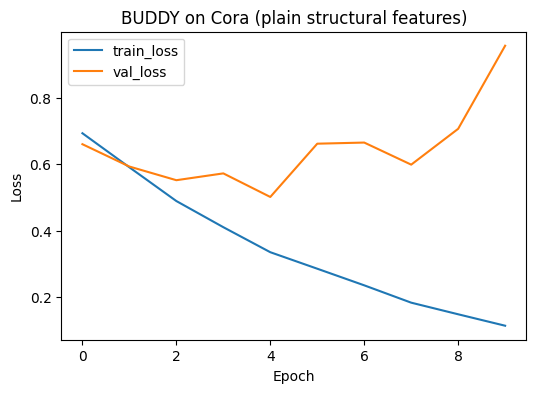

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(history_plain["train_loss"], label="train_loss")
if len(history_plain["val_loss"]) > 0:
    plt.plot(history_plain["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BUDDY on Cora (plain structural features)")
plt.legend()
plt.show()

In [9]:
set_seed(42)

buddy_model_log = BUDDY(
    node_feature_dim=train_data.x.size(1),
    num_hops=buddy_config["num_hops"],
    predictor_hidden_channels=buddy_config["predictor_hidden_channels"],
    dropout=buddy_config["dropout"],
    structural_use_log=True,
).to(device)

optimizer_log = optim.Adam(
    buddy_model_log.parameters(),
    lr=buddy_config["lr"],
    weight_decay=buddy_config["weight_decay"],
)

print(buddy_model_log)
print("Trainable parameters:", count_parameters(buddy_model_log))

BUDDY(
  (predictor): BUDDYLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=5745, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)
Trainable parameters: 367809


In [10]:
buddy_model_log.eval()

with torch.no_grad():
    logits_log = buddy_model_log(
        buddy_cache=buddy_cache,
        edge_label_index=edge_label_index_batch,
    )

print("logits_log shape:", logits_log.shape)
print(logits_log)

logits_log shape: torch.Size([16])
tensor([-0.0882, -0.0957, -0.1028, -0.0908, -0.1286, -0.1049, -0.0702, -0.0846,
        -0.1032, -0.1016, -0.0954, -0.0980, -0.0814, -0.0819, -0.1019, -0.0847],
       device='cuda:0')


In [11]:
history_log = fit_buddy(
    model=buddy_model_log,
    optimizer=optimizer_log,
    train_data=train_data,
    val_data=val_data,
    buddy_cache=buddy_cache,
    device=device,
    epochs=buddy_config["epochs"],
    verbose=True,
    patience=buddy_config["patience"],
    checkpoint_path=project_root / "results" / "models" / "buddy_cora_log_best.pt",
    restore_best_model=True,
)

print("Training finished (log structural features).")
print("Best epoch:", history_log["best_epoch"])
print("Best val loss:", history_log["best_val_loss"])
print("Epochs ran:", history_log["epochs_ran"])
print("Stopped early:", history_log["stopped_early"])

Training BUDDY:  73%|███████▎  | 11/15 [00:00<00:00, 24.79it/s, best_val=0.5064, train_loss=0.0996, val_loss=0.6632]

Training finished (log structural features).
Best epoch: 7
Best val loss: 0.5064332485198975
Epochs ran: 12
Stopped early: True


In [12]:
train_metrics_log = evaluate_split_buddy(
    buddy_model_log,
    train_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

val_metrics_log = evaluate_split_buddy(
    buddy_model_log,
    val_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

test_metrics_log = evaluate_split_buddy(
    buddy_model_log,
    test_data,
    buddy_cache,
    device,
    hits_ks=[100],
)

print("Train metrics (log):", train_metrics_log)
print("Val metrics (log):", val_metrics_log)
print("Test metrics (log):", test_metrics_log)

Train metrics (log): {'loss': 0.20971296727657318, 'auc': 0.9930247365819606, 'ap': 0.991400755976771, 'hits@100': 0.9699675440788269}
Val metrics (log): {'loss': 0.5064332485198975, 'auc': 0.8633145980434165, 'ap': 0.8809086412143627, 'hits@100': 0.766603410243988}
Test metrics (log): {'loss': 0.4742145836353302, 'auc': 0.8915770086026817, 'ap': 0.9099681878366523, 'hits@100': 0.7232227325439453}


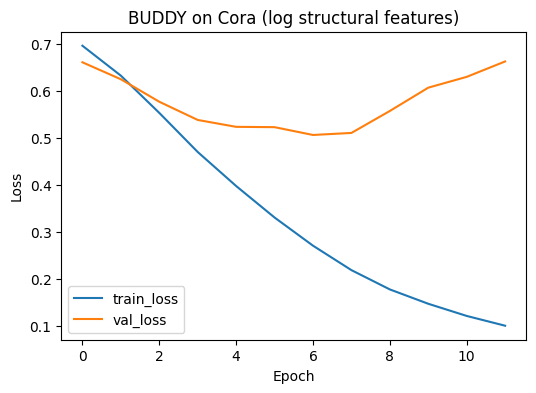

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(history_log["train_loss"], label="train_loss")
if len(history_log["val_loss"]) > 0:
    plt.plot(history_log["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BUDDY on Cora (log structural features)")
plt.legend()
plt.show()

In [14]:
print("Plain structural features:")
print("Best epoch:", history_plain["best_epoch"])
print("Best val loss:", history_plain["best_val_loss"])
print("Train:", train_metrics_plain)
print("Val  :", val_metrics_plain)
print("Test :", test_metrics_plain)

print("\nLog-scaled structural features:")
print("Best epoch:", history_log["best_epoch"])
print("Best val loss:", history_log["best_val_loss"])
print("Train:", train_metrics_log)
print("Val  :", val_metrics_log)
print("Test :", test_metrics_log)

Plain structural features:
Best epoch: 5
Best val loss: 0.5010969042778015
Train: {'loss': 0.268827885389328, 'auc': 0.9874451846854445, 'ap': 0.9810024033401544, 'hits@100': 0.9431818127632141}
Val  : {'loss': 0.5010969042778015, 'auc': 0.8593791069711841, 'ap': 0.8648669843622802, 'hits@100': 0.7571157217025757}
Test : {'loss': 0.462864488363266, 'auc': 0.8836481660340063, 'ap': 0.9038639259606666, 'hits@100': 0.7175355553627014}

Log-scaled structural features:
Best epoch: 7
Best val loss: 0.5064332485198975
Train: {'loss': 0.20971296727657318, 'auc': 0.9930247365819606, 'ap': 0.991400755976771, 'hits@100': 0.9699675440788269}
Val  : {'loss': 0.5064332485198975, 'auc': 0.8633145980434165, 'ap': 0.8809086412143627, 'hits@100': 0.766603410243988}
Test : {'loss': 0.4742145836353302, 'auc': 0.8915770086026817, 'ap': 0.9099681878366523, 'hits@100': 0.7232227325439453}


## TIMER CHECKING

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import torch
from torch import optim

from src.utils.helpers import set_seed, get_device
from src.utils.timer import (
    time_buddy_preprocessing,
    time_training_epoch,
    time_inference_full_split,
)
from src.data_processing.load_data import get_data_object
from src.data_processing.preprocess import prepare_link_prediction_data
from src.models.elph import ELPHEdgeAware
from src.models.buddy import BUDDY
from src.models.train import train_one_epoch_buddy, train_one_epoch
from src.evaluation.evaluate import evaluate_split_buddy, evaluate_split
from src.utils.buddy_helpers import build_buddy_cache

In [2]:
set_seed(42)
device = get_device()

dataset_name = "Cora"

timing_config = {
    "num_hops": 2,
    "minhash_num_perm": 128,
    "hll_p": 8,
    "feature_propagation": "mean",
    "hidden_channels": 64,
    "predictor_hidden_channels": 64,
    "message_hidden_channels": 64,
    "update_hidden_channels": 64,
    "dropout": 0.2,
    "lr": 1e-2,
    "weight_decay": 1e-4,
}

print("Device:", device)
print("Dataset:", dataset_name)
print(timing_config)

data = get_data_object(dataset_name, root=project_root / "data")
train_data, val_data, test_data = prepare_link_prediction_data(dataset_name, data)

print(train_data)
print(val_data)
print(test_data)

Device: cuda
Dataset: Cora
{'num_hops': 2, 'minhash_num_perm': 128, 'hll_p': 8, 'feature_propagation': 'mean', 'hidden_channels': 64, 'predictor_hidden_channels': 64, 'message_hidden_channels': 64, 'update_hidden_channels': 64, 'dropout': 0.2, 'lr': 0.01, 'weight_decay': 0.0001}
Data(x=[2708, 1433], edge_index=[2, 7392], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[7392], edge_label_index=[2, 7392])
Data(x=[2708, 1433], edge_index=[2, 7392], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[1054], edge_label_index=[2, 1054])
Data(x=[2708, 1433], edge_index=[2, 8446], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708], edge_label=[2110], edge_label_index=[2, 2110])


In [3]:
elphedge_model = ELPHEdgeAware(
    in_channels=train_data.x.size(1),
    hidden_channels=timing_config["hidden_channels"],
    predictor_hidden_channels=timing_config["predictor_hidden_channels"],
    num_hops=timing_config["num_hops"],
    minhash_num_perm=timing_config["minhash_num_perm"],
    hll_p=timing_config["hll_p"],
    message_hidden_channels=timing_config["message_hidden_channels"],
    update_hidden_channels=timing_config["update_hidden_channels"],
    dropout=timing_config["dropout"],
    use_log_features=True,
).to(device)

optimizer_elph_edge = optim.Adam(
    elphedge_model.parameters(),
    lr=timing_config["lr"],
    weight_decay=timing_config["weight_decay"],
)

print(elphedge_model)

ELPHEdgeAware(
  (encoder): ELPHEdgeAwareEncoder(
    (input_proj): Linear(in_features=1433, out_features=64, bias=True)
    (layers): ModuleList(
      (0): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=132, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (1): ELPHEdgeAwareLayerLog1p(
        (message_mlp): Sequential(
          (0): Linear(in_features=134, out_features=64, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=64, out_features=64, bias=True)
        )
        (update_mlp): Sequential(
     

In [7]:
train_loss_elph_edge, train_time_elph_edge = time_training_epoch(
    train_one_epoch_fn=train_one_epoch,
    model=elphedge_model,
    optimizer=optimizer_elph_edge,
    train_data=train_data,
    sync_device=device,
)

print("ELPHEdgeAware train_loss:", train_loss_elph_edge)
print("ELPHEdgeAware train_time_per_epoch_s:", train_time_elph_edge)

ELPHEdgeAware train_loss: 0.7071386575698853
ELPHEdgeAware train_time_per_epoch_s: 2.437341600001673


In [8]:
metrics_elph_edge, inference_time_elph_edge = time_inference_full_split(
    evaluate_split_fn=evaluate_split,
    model=elphedge_model,
    data=test_data,
    sync_device=device,
    hits_ks=[100],
)

print("ELPHEdgeAware inference_time_s:", inference_time_elph_edge)
print("ELPHEdgeAware test metrics snapshot:", metrics_elph_edge)

ELPHEdgeAware inference_time_s: 8.709220999997342
ELPHEdgeAware test metrics snapshot: {'loss': 0.7157314419746399, 'auc': 0.696582736236832, 'ap': 0.718462452022675, 'hits@100': 0.34786728024482727}


In [11]:
buddy_model = BUDDY(
    node_feature_dim=train_data.x.size(1),
    num_hops=timing_config["num_hops"],
    predictor_hidden_channels=timing_config["predictor_hidden_channels"],
    dropout=timing_config["dropout"],
    structural_use_log=True,
).to(device)

optimizer_buddy = optim.Adam(
    buddy_model.parameters(),
    lr=timing_config["lr"],
    weight_decay=timing_config["weight_decay"],
)

print(buddy_model)

BUDDY(
  (predictor): BUDDYLinkPredictor(
    (mlp): Sequential(
      (0): Linear(in_features=5745, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)


In [12]:
buddy_cache, buddy_preproc_time = time_buddy_preprocessing(
    build_buddy_cache_fn=build_buddy_cache,
    x=train_data.x.to(device),
    edge_index=train_data.edge_index.to(device),
    num_hops=timing_config["num_hops"],
    minhash_num_perm=timing_config["minhash_num_perm"],
    hll_p=timing_config["hll_p"],
    feature_propagation=timing_config["feature_propagation"],
    cache_device=device,
    timer_device=device,
)

print("BUDDY preprocessing time (s):", buddy_preproc_time)
print("Cache keys:", buddy_cache.keys())

BUDDY preprocessing time (s): 1.7854627999913646
Cache keys: dict_keys(['num_nodes', 'num_hops', 'propagated_x_hops', 'minhash_hops', 'hll_hops', 'cardinality_hops'])


In [13]:
train_loss_buddy, train_time_buddy = time_training_epoch(
    train_one_epoch_fn=train_one_epoch_buddy,
    model=buddy_model,
    optimizer=optimizer_buddy,
    train_data=train_data,
    buddy_cache=buddy_cache,
    sync_device=device,
)

print("BUDDY train_loss:", train_loss_buddy)
print("BUDDY train_time_per_epoch_s:", train_time_buddy)

BUDDY train_loss: 0.6954012513160706
BUDDY train_time_per_epoch_s: 0.21400839999841992


In [14]:
metrics_buddy, inference_time_buddy = time_inference_full_split(
    evaluate_split_fn=evaluate_split_buddy,
    model=buddy_model,
    data=test_data,
    buddy_cache=buddy_cache,
    sync_device=device,
    hits_ks=[100],
)

print("BUDDY inference_time_s:", inference_time_buddy)
print("BUDDY test metrics snapshot:", metrics_buddy)

BUDDY inference_time_s: 0.21904660000291187
BUDDY test metrics snapshot: {'loss': 0.7040739059448242, 'auc': 0.7959349520451022, 'ap': 0.7767421601031086, 'hits@100': 0.3744075894355774}


In [15]:
runtime_rows = [
    {
        "model": "ELPHEdgeAware_log",
        "dataset": dataset_name,
        "preproc_time_s": 0.0,
        "train_time_per_epoch_s": train_time_elph_edge,
        "inference_time_s": inference_time_elph_edge,
    },
    {
        "model": "BUDDY_log",
        "dataset": dataset_name,
        "preproc_time_s": buddy_preproc_time,
        "train_time_per_epoch_s": train_time_buddy,
        "inference_time_s": inference_time_buddy,
    },
]

runtime_df = pd.DataFrame(runtime_rows)
runtime_df

,model,dataset,preproc_time_s,train_time_per_epoch_s,inference_time_s
0,ELPHEdgeAware_log,Cora,0.000000,2.437342,8.709221
1,BUDDY_log,Cora,1.785463,0.214008,0.219047


## TABLE WORK CHECKING

In [2]:
import sys
from pathlib import Path

r_folder = Path.cwd().parent
if str(r_folder) not in sys.path:
    sys.path.append(str(r_folder))
    
from src.utils.helpers import results_dir, models_dir, plots_dir, tables_dir
from src.utils.table_tools import (
    record_experiment_result,
    record_runtime_result,
    load_result_rows,
    load_runtime_rows,
    export_all_current_summaries,
)

print("results_dir :", results_dir())
print("models_dir  :", models_dir())
print("plots_dir   :", plots_dir())
print("tables_dir  :", tables_dir())

print("\nExists check:")
print(results_dir().exists(), models_dir().exists(), plots_dir().exists(), tables_dir().exists())

results_dir : D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results
models_dir  : D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\models
plots_dir   : D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\plots
tables_dir  : D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\tables

Exists check:
True True True True


In [3]:
fake_result_row = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 1,
    "metric_name": "hits@100",
    "monitor": "val_hits@K",
    "monitor_hits_k": 100,
    "best_epoch": 12,
    "epochs_trained": 15,
    "train_loss": 0.0831,
    "val_loss": 0.2145,
    "test_loss": 0.2278,
    "val_auc": 0.9123,
    "test_auc": 0.9038,
    "val_ap": 0.9181,
    "test_ap": 0.9075,
    "val_hits@K": 86.20,
    "test_hits@K": 84.90,
}

result_path = record_experiment_result(fake_result_row, save_csv=True)
print("Saved result JSON to:", result_path)

Saved result JSON to: D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed1.json


In [4]:
fake_runtime_row = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 1,
    "preprocess_sec": 1.237,
    "train_sec": 4.821,
    "inference_sec": 0.413,
}

runtime_path = record_runtime_result(fake_runtime_row, save_csv=True)
print("Saved runtime JSON to:", runtime_path)

Saved runtime JSON to: D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed1_runtime.json


In [5]:
result_rows = load_result_rows(include_runtime=False)
runtime_rows = load_runtime_rows()

print("Result rows loaded:", len(result_rows))
print("Runtime rows loaded:", len(runtime_rows))

print("\nLatest result row:")
print(result_rows[-1])

print("\nLatest runtime row:")
print(runtime_rows[-1])

Result rows loaded: 3
Runtime rows loaded: 3

Latest result row:
{'dataset': 'Cora', 'model': 'ELPH', 'cfg_name': 'CORA_ELPH_PRIMARY', 'seed': 3, 'metric_name': 'hits@100', 'monitor': 'val_hits@K', 'monitor_hits_k': 100, 'best_epoch': 13, 'epochs_trained': 16, 'train_loss': 0.081, 'val_loss': 0.2117, 'test_loss': 0.226, 'val_auc': 0.9135, 'test_auc': 0.9044, 'val_ap': 0.9192, 'test_ap': 0.9081, 'val_hits@K': 86.5, 'test_hits@K': 85.1}

Latest runtime row:
{'dataset': 'Cora', 'model': 'ELPH', 'cfg_name': 'CORA_ELPH_PRIMARY', 'seed': 3, 'preprocess_sec': 1.255, 'train_sec': 4.903, 'inference_sec': 0.42}


In [6]:
fake_result_row_2 = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 2,
    "metric_name": "hits@100",
    "monitor": "val_hits@K",
    "monitor_hits_k": 100,
    "best_epoch": 11,
    "epochs_trained": 14,
    "train_loss": 0.0792,
    "val_loss": 0.2088,
    "test_loss": 0.2241,
    "val_auc": 0.9149,
    "test_auc": 0.9052,
    "val_ap": 0.9200,
    "test_ap": 0.9090,
    "val_hits@K": 86.80,
    "test_hits@K": 85.40,
}

fake_result_row_3 = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 3,
    "metric_name": "hits@100",
    "monitor": "val_hits@K",
    "monitor_hits_k": 100,
    "best_epoch": 13,
    "epochs_trained": 16,
    "train_loss": 0.0810,
    "val_loss": 0.2117,
    "test_loss": 0.2260,
    "val_auc": 0.9135,
    "test_auc": 0.9044,
    "val_ap": 0.9192,
    "test_ap": 0.9081,
    "val_hits@K": 86.50,
    "test_hits@K": 85.10,
}

fake_runtime_row_2 = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 2,
    "preprocess_sec": 1.201,
    "train_sec": 4.765,
    "inference_sec": 0.401,
}

fake_runtime_row_3 = {
    "dataset": "Cora",
    "model": "ELPH",
    "cfg_name": "CORA_ELPH_PRIMARY",
    "seed": 3,
    "preprocess_sec": 1.255,
    "train_sec": 4.903,
    "inference_sec": 0.420,
}

record_experiment_result(fake_result_row_2, save_csv=False)
record_experiment_result(fake_result_row_3, save_csv=False)
record_runtime_result(fake_runtime_row_2, save_csv=False)
record_runtime_result(fake_runtime_row_3, save_csv=False)

print("Added seeds 2 and 3.")

Added seeds 2 and 3.


In [7]:
accuracy_csv_path, runtime_csv_path = export_all_current_summaries()

print("Accuracy summary saved to:", accuracy_csv_path)
print("Runtime summary saved to :", runtime_csv_path)

Accuracy summary saved to: D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\tables\final_accuracy_summary.csv
Runtime summary saved to : D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\tables\final_runtime_summary.csv


In [8]:
import pandas as pd

acc_df = pd.read_csv(accuracy_csv_path)
rt_df = pd.read_csv(runtime_csv_path)

print("Accuracy summary:")
display(acc_df)

print("Runtime summary:")
display(rt_df)

Accuracy summary:


,dataset,model,cfg_name,metric_name,monitor,monitor_hits_k,n_seeds,seeds,val_loss_mean,val_loss_std,...,val_ap_display,test_ap_mean,test_ap_std,test_ap_display,val_hits@K_mean,val_hits@K_std,val_hits@K_display,test_hits@K_mean,test_hits@K_std,test_hits@K_display
0,Cora,ELPH,CORA_ELPH_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.211667,0.00285,...,0.92±0.00,0.9082,0.000755,0.91±0.00,86.5,0.3,86.50±0.30,85.133333,0.251661,85.13±0.25


Runtime summary:


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,preprocess_sec_display,train_sec_mean,train_sec_std,train_sec_display,inference_sec_mean,inference_sec_std,inference_sec_display
0,Cora,ELPH,CORA_ELPH_PRIMARY,3,"1,2,3",1.231,0.027495,1.231±0.027,4.829667,0.069407,4.830±0.069,0.411333,0.009609,0.411±0.010


In [9]:
acc_row = acc_df[
    (acc_df["dataset"] == "Cora") &
    (acc_df["model"] == "ELPH") &
    (acc_df["cfg_name"] == "CORA_ELPH_PRIMARY")
]

rt_row = rt_df[
    (rt_df["dataset"] == "Cora") &
    (rt_df["model"] == "ELPH") &
    (rt_df["cfg_name"] == "CORA_ELPH_PRIMARY")
]

print("Filtered accuracy row:")
display(acc_row)

print("Filtered runtime row:")
display(rt_row)

Filtered accuracy row:


,dataset,model,cfg_name,metric_name,monitor,monitor_hits_k,n_seeds,seeds,val_loss_mean,val_loss_std,...,val_ap_display,test_ap_mean,test_ap_std,test_ap_display,val_hits@K_mean,val_hits@K_std,val_hits@K_display,test_hits@K_mean,test_hits@K_std,test_hits@K_display
0,Cora,ELPH,CORA_ELPH_PRIMARY,hits@100,val_hits@K,100,3,"1,2,3",0.211667,0.00285,...,0.92±0.00,0.9082,0.000755,0.91±0.00,86.5,0.3,86.50±0.30,85.133333,0.251661,85.13±0.25


Filtered runtime row:


,dataset,model,cfg_name,n_seeds,seeds,preprocess_sec_mean,preprocess_sec_std,preprocess_sec_display,train_sec_mean,train_sec_std,train_sec_display,inference_sec_mean,inference_sec_std,inference_sec_display
0,Cora,ELPH,CORA_ELPH_PRIMARY,3,"1,2,3",1.231,0.027495,1.231±0.027,4.829667,0.069407,4.830±0.069,0.411333,0.009609,0.411±0.010


In [10]:
print("results/*.json")
for p in sorted(results_dir().glob("*.json")):
    print(" -", p.name)

print("\nresults/tables/*.csv")
for p in sorted(tables_dir().glob("*.csv")):
    print(" -", p.name)

results/*.json
 - CORA_ELPH_PRIMARY_seed1.json
 - CORA_ELPH_PRIMARY_seed1_runtime.json
 - CORA_ELPH_PRIMARY_seed2.json
 - CORA_ELPH_PRIMARY_seed2_runtime.json
 - CORA_ELPH_PRIMARY_seed3.json
 - CORA_ELPH_PRIMARY_seed3_runtime.json

results/tables/*.csv
 - CORA_ELPH_PRIMARY_seed1.csv
 - CORA_ELPH_PRIMARY_seed1_runtime.csv
 - final_accuracy_summary.csv
 - final_runtime_summary.csv


In [11]:
import os
from src.utils.helpers import results_dir, tables_dir

targets = [
    "CORA_ELPH_PRIMARY_seed1.json",
    "CORA_ELPH_PRIMARY_seed2.json",
    "CORA_ELPH_PRIMARY_seed3.json",
    "CORA_ELPH_PRIMARY_seed1_runtime.json",
    "CORA_ELPH_PRIMARY_seed2_runtime.json",
    "CORA_ELPH_PRIMARY_seed3_runtime.json",
]

for name in targets:
    path = results_dir() / name
    if path.exists():
        path.unlink()
        print("Removed", path)

for name in [
    "CORA_ELPH_PRIMARY_seed1.csv",
    "CORA_ELPH_PRIMARY_seed1_runtime.csv",
    "final_accuracy_summary.csv",
    "final_runtime_summary.csv",
]:
    path = tables_dir() / name
    if path.exists():
        path.unlink()
        print("Removed", path)

Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed1.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed2.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed3.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed1_runtime.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed2_runtime.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\CORA_ELPH_PRIMARY_seed3_runtime.json
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\tables\CORA_ELPH_PRIMARY_seed1.csv
Removed D:\McMaster\2026_Winter\CAS_747\Project\CAS747_finalproject\Yucheng_Yao\results\tables\CORA_ELPH_PRIMARY_seed1_runtime.csv
Removed D:\McMaster\